# Kostic et al. 2023 Metrics 

## Functions for implementing and analysing metrics

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

from kooplearn._linalg import eigh_rank_reveal, spd_neg_pow, weighted_norm
from kooplearn.datasets import compute_prinz_potential_eig, make_prinz_potential
from kooplearn.kernel import KernelRidge


def operator_norm_error(true_operator: np.ndarray, estimated_operator: np.ndarray):
    r"""Operator norm error proxy for a Koopman estimator.

    Computes the operator norm discrepancy between the true action
    :math:`A_\pi S` and the estimated action :math:`S \widehat{G}`:

    .. math::

        \mathcal{E}(\widehat{G}) := \|A_\pi S - S \widehat{G}\|.

    Since "kooplearn" does not currently expose :math:`A_\pi` or the embedding
    operator :math:`S` explicitly, this function works with their actions on a
    common finite-dimensional representation. In practice, the caller should pass
    matrices or vectors representing the two quantities to be compared.
    """
    true_operator = np.asanyarray(true_operator)
    estimated_operator = np.asanyarray(estimated_operator)

    if true_operator.shape != estimated_operator.shape:
        raise ValueError(
            "true_operator and estimated_operator must have the same "
            f"shape, got {true_operator.shape} and "
            f"{estimated_operator.shape}."
        )

    diff = true_operator - estimated_operator
    if diff.ndim == 1:
        return float(np.linalg.norm(diff))
    return float(np.linalg.norm(diff, ord=2))


def metric_distortion(psi, C):
    r"""Empirical metric distortion :math:`\widehat\eta_i = \|\widehat\psi_i\|_{\mathcal H} /
    \sqrt{\langle \widehat C \widehat\psi_i, \widehat\psi_i\rangle}`.

    Parameters
    ----------
    psi : ndarray, shape (n,) or (n, k)
        Eigenfunction(s) evaluated at the *training* points. If 2D, each
        column is treated as a separate eigenfunction (see `weighted_norm`).
    C : ndarray, shape (n, n)
        Empirical (kernel-based) covariance, i.e. ``model.kernel_X / n_samples``.
    """
    psi = np.asarray(psi)
    n = C.shape[0]

    # ||psi||_H via the reproducing property: needs the *inverse* Gram, since
    # C = K_X / n is the Gram-based covariance, not the RKHS metric itself.
    C_inv = spd_neg_pow(C * n, exponent=-1.0)  # i.e. K_X^{-1}
    rkhs_norm = weighted_norm(psi, M=C_inv)

    # <C psi, psi> = (1/n)||psi(X)||_2^2, i.e. weighted_norm with M=None, squared, over n
    empirical_norm = weighted_norm(psi, M=None) / np.sqrt(n)

    with np.errstate(divide="ignore", invalid="ignore"):
        eta = rkhs_norm / empirical_norm
    eta = np.where(empirical_norm > 0, eta, np.nan)
    return eta if psi.ndim == 2 else float(eta)


def spectral_bias(eigenfunction, C, rho):
    r"""Empirical spectral bias :math:`\hat s_i = \widehat\eta_i \, \rho_{r+1}`."""
    eta = metric_distortion(eigenfunction, C)
    s_hat = eta * rho
    return float(s_hat), eta


def _top_sv(C, r):
    """(r+1)-st eigenvalue of a symmetric PSD matrix, via eigh_rank_reveal."""
    raw_vals, raw_vecs = np.linalg.eigh(np.asarray(C))
    _, top_vals, _ = eigh_rank_reveal(raw_vals, raw_vecs, rank=r + 1)
    if len(top_vals) <= r:
        return 0.0
    return float(top_vals[-1])


# --- truncation helpers ---
def pcr_truncation(C, r):
    r""":math:`\rho_{r+1}(\widehat G^{PCR}) = \sigma_{r+1}(\widehat C)`."""
    return _top_sv(C, r)


# kDMD uses the same (r+1)-st eigenvalue of the empirical covariance as PCR
kdmd_truncation = pcr_truncation


def rrr_truncation(C, T, r, cutoff=None):
    r""":math:`\rho_{r+1}(\widehat G^{RRR}) = \sigma_{r+1}(\widehat C^{-1/2}\widehat T)`."""
    C_inv_sqrt = spd_neg_pow(np.asarray(C), exponent=-0.5, cutoff=cutoff)
    A = C_inv_sqrt @ np.asarray(T)
    svals = np.linalg.svd(A, compute_uv=False)
    if r >= len(svals):
        return 0.0
    return float(svals[r])


# --- spectral gap (top-two magnitude eigenvalues) ---
def spectral_gap(eigenvalues):
    mags = np.sort(np.abs(eigenvalues))[::-1]
    return float(mags[0] - mags[1]) if len(mags) > 1 else np.nan


# --- spurious eigenvalues vs reference ---


def spurious_ref(est, ref, delta):
    dist = np.abs(est[:, None] - ref[None, :])
    return int(np.sum(dist.min(axis=1) > delta))


def spurious_residual(eigenvalues, psi_X_val, psi_Y_val, delta, relative=True):
    r"""Data-driven spurious-eigenpair check (see paper Appendix C, Remark 4).

    Flags eigenpairs that fail the empirical consistency check
    :math:`\hat\psi_i(y_j) \approx \hat\lambda_i \hat\psi_i(x_j)` on a
    held-out validation set.

    Parameters
    ----------
    eigenvalues : ndarray, shape (r,)
        Estimated eigenvalues, same order as columns of psi_X_val/psi_Y_val.
    psi_X_val : ndarray, shape (n_val, r)
        Eigenfunctions evaluated at validation inputs x_j.
    psi_Y_val : ndarray, shape (n_val, r)
        Same eigenfunctions evaluated at outputs y_j.
    delta : float
        Threshold on the residual score.
    relative : bool
        If True, normalize residual by ||psi_X_val||.

    Returns
    -------
    n_spurious : int
    scores : ndarray, shape (r,)
    """
    eigenvalues = np.asarray(eigenvalues)
    n_val = psi_X_val.shape[0]

    resid = psi_Y_val - psi_X_val * eigenvalues[None, :]
    resid_norm = weighted_norm(resid) / np.sqrt(n_val)

    if relative:
        base_norm = weighted_norm(psi_X_val) / np.sqrt(n_val)
        scores = np.full_like(resid_norm, np.nan, dtype=float)

        ok = np.isfinite(base_norm) & (base_norm > 0)
        scores[ok] = resid_norm[ok] / base_norm[ok]
    else:
        scores = resid_norm

    n_spurious = int(np.sum(scores > delta))
    return n_spurious, scores


# --- compilation function for analysing spectral metrics ---
def analyse_spectrum(modes_records, trials_records, out_prefix):
    modes_df = pd.DataFrame(modes_records).copy()
    trials_df = pd.DataFrame(trials_records).copy()

    if "spectral_gap" not in modes_df.columns:
        raise ValueError(
            f"modes_df is missing 'spectral_gap'. Columns: {modes_df.columns.tolist()}"
        )

    summary = modes_df.groupby(
        ["kernel", "kind", "method", "eigenfunction_id"], as_index=False
    ).agg(
        n=("spectral_bias", "size"),
        bias_mean=("spectral_bias", "mean"),
        bias_std=("spectral_bias", "std"),
        dist_mean=("metric_distortion", "mean"),
        trunc_mean=("truncation", "mean"),
        spurious_mean=("residual_spurious_score", "mean"),
        spurious_std=("residual_spurious_score", "std"),
    )

    rows = []
    for (kernel, kind, method), g in modes_df.groupby(["kernel", "kind", "method"]):
        gg = g[["spectral_bias", "spectral_gap"]].dropna()
        corr = gg["spectral_bias"].corr(gg["spectral_gap"]) if len(gg) > 1 else np.nan
        rows.append(
            {
                "kernel": kernel,
                "kind": kind,
                "method": method,
                "bias_gap_corr": corr,
            }
        )
    corr_df = pd.DataFrame(rows)

    summary.to_csv(f"{out_prefix}_summary.csv", index=False)
    modes_df.to_csv(f"{out_prefix}_metrics.csv", index=False)
    trials_df.to_csv(f"{out_prefix}_trials.csv", index=False)
    corr_df.to_csv(f"{out_prefix}_corr.csv", index=False)

    fig1, ax = plt.subplots(figsize=(6.5, 4.5))
    for (kernel, kind, method), g in modes_df.groupby(["kernel", "kind", "method"]):
        ax.scatter(
            g["spectral_bias"],
            g["spectral_gap"],
            s=20,
            alpha=0.7,
            label=f"{kernel}, {kind} / {method}",
        )
    ax.set_xlabel("Spectral bias")
    ax.set_ylabel("Spectral gap")
    ax.legend(frameon=False, fontsize=8)
    ax.set_title("Spectral bias vs Spectral gap")
    fig1.tight_layout()
    fig1.savefig(f"{out_prefix}_gap_scatter.png", dpi=200, bbox_inches="tight")
    plt.close(fig1)

    fig2, ax = plt.subplots(figsize=(6.5, 4.5))
    for (kernel, kind, method), g in modes_df.groupby(["kernel", "kind", "method"]):
        ax.scatter(
            g["spectral_bias"],
            g["residual_spurious_score"],
            s=20,
            alpha=0.7,
            label=f"{kernel}, {kind} / {method}",
        )
    ax.set_xlabel("Spectral bias")
    ax.set_ylabel("Residual spurious score")
    ax.legend(frameon=False, fontsize=8)
    ax.set_title("Spectral bias vs Residual spurious score")
    fig2.tight_layout()
    fig2.savefig(f"{out_prefix}_spurious_scatter.png", dpi=200, bbox_inches="tight")
    plt.close(fig2)

    return modes_df, trials_df, summary, corr_df, fig1, fig2


## RQ1

### Overdamped Langevin Spectral Analysis

In [ ]:
x = np.linspace(-2, 2, 2048 + 1)
gamma = 1.0
sigma = 2.0
dt = 1e-4
subsample = 100
n_train = 2000
n_val = 500
n_trials = 10
n_show = 3
# training simulation:
n_steps_train = n_train * subsample
# validation simulation:
n_steps_val = n_val * subsample

data = make_prinz_potential(X0=0, n_steps=n_steps_train, gamma=gamma, sigma=sigma, random_state=0)
data = data.iloc[::subsample][:n_train]


# Validation set
n_val = 500
data_val = make_prinz_potential(
    X0=0, n_steps=n_steps_val, gamma=gamma, sigma=sigma, random_state=999
)  # different seed
data_val = data_val.iloc[::subsample][:n_val]

X_val = data_val.iloc[:-1].values
Y_val = data_val.iloc[1:].values


vals_ref = compute_prinz_potential_eig(gamma, sigma, dt, num_components=5)

trials_records = []
modes_records = []
for method, reduced_rank in zip(
    ["Principal Components (kDMD)", "Reduced Rank"],
    [False, True],
):
    for trial in tqdm(range(n_trials), desc=method):
        model = KernelRidge(
            n_components=5,
            reduced_rank=reduced_rank,
            gamma=12.5,
            kernel="rbf",
            alpha=1e-6,
            random_state=trial,  # vary the seed across trials
        )
        model.fit(data)

        n = model.kernel_X_.shape[0]
        C = model.kernel_X_ / n
        T = model.kernel_YX_ / n

        vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
        sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
        vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

        gap = spectral_gap(vals_hat)
        n_spur = spurious_ref(vals_hat, vals_ref, delta=0.05)

        # Evaluate the SAME fitted eigenfunctions at validation points (unsorted call, then reorder)
        vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
        _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)

        # sanity check: eigenvalues from this call should match vals_hat up to the same permutation
        assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
            "eig() ordering changed between calls"
        )

        psi_X_val = psi_X_val_raw[:, sort_perm]
        psi_Y_val = psi_Y_val_raw[:, sort_perm]

        n_residual, spur_scores = spurious_residual(
            vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
        )

        fit_rank = model.rank_
        rho = (
            kdmd_truncation(C, fit_rank)
            if method == "Principal Components (kDMD)"
            else rrr_truncation(C, T, fit_rank)
        )

        modes = model.dynamical_modes(data)
        n_modes = modes.n_modes
        trials_records.append(
            {
                "kind": "N/A",
                "method": method,
                "trial": trial,
                "spurious_ref_count": int(n_spur),  # reference against true spectrum σ(A)
                "spurious_residual_count": int(n_residual),  # data-driven, appendix-style
                "spectral_gap": gap,
                "rank": fit_rank,
            }
        )

        modes = model.dynamical_modes(data)
        n_modes = modes.n_modes
        for j in range(n_modes):
            bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
            modes_records.append(
                {
                    "kind": "N/A",
                    "kernel": "rbf",
                    "method": method,
                    "trial": trial,
                    "eigenfunction_id": j + 1,
                    "spectral_bias": float(bias),
                    "metric_distortion": float(distortion),
                    "truncation": float(rho),
                    "residual_spurious_score": float(spur_scores[j]),
                    "spectral_gap": gap,
                    "est_eig_real": float(np.real(vals_hat[j])),
                    "est_eig_imag": float(np.imag(vals_hat[j])),
                }
            )

modes_df, trials_df, summary, corr_df, fig1, fig2 = analyse_spectrum(
    modes_records, trials_records, out_prefix="langevin_full"
)
print(modes_df)
print(trials_df)
print(summary)
print(corr_df)


Reduced Rank: 100%|██████████| 10/10 [57:56<00:00, 347.66s/it]


    kind kernel                       method  trial  eigenfunction_id  \
0    N/A    rbf  Principal Components (kDMD)      0                 1   
1    N/A    rbf  Principal Components (kDMD)      0                 1   
2    N/A    rbf  Principal Components (kDMD)      0                 2   
3    N/A    rbf  Principal Components (kDMD)      0                 2   
4    N/A    rbf  Principal Components (kDMD)      0                 3   
..   ...    ...                          ...    ...               ...   
195  N/A    rbf                 Reduced Rank      9                 3   
196  N/A    rbf                 Reduced Rank      9                 4   
197  N/A    rbf                 Reduced Rank      9                 4   
198  N/A    rbf                 Reduced Rank      9                 5   
199  N/A    rbf                 Reduced Rank      9                 5   

     spectral_bias  metric_distortion  truncation  residual_spurious_score  \
0         0.581365          11.980713    0.04

In [ ]:
from tqdm import tqdm

from kooplearn.datasets import compute_prinz_potential_eig, make_prinz_potential
from kooplearn.kernel import KernelRidge


def langevin_kernel_sweep(
    gammas,
    *,
    methods=(("Principal Components (kDMD)", False), ("Reduced Rank", True)),
    n_components=5,
    alpha=1e-6,
    gamma_dynamics=1.0,
    sigma=2.0,
    dt=1e-4,
    subsample=100,
    n_train=2000,
    n_val=500,
    n_trials=10,
    kernel_name="rbf",
):
    """
    Run the Prinz/Langevin experiment over a family of RBF bandwidths.
    Returns outputs in the same schema expected by analyse_spectrum().
    """
    n_steps_train = n_train * subsample
    n_steps_val = n_val * subsample

    data = make_prinz_potential(
        X0=0,
        n_steps=n_steps_train,
        gamma=gamma_dynamics,
        sigma=sigma,
        random_state=0,
    )
    data = data.iloc[::subsample][:n_train]

    data_val = make_prinz_potential(
        X0=0,
        n_steps=n_steps_val,
        gamma=gamma_dynamics,
        sigma=sigma,
        random_state=999,
    )
    data_val = data_val.iloc[::subsample][:n_val]

    X_val = data_val.iloc[:-1].values
    Y_val = data_val.iloc[1:].values

    vals_ref = compute_prinz_potential_eig(gamma_dynamics, sigma, dt, num_components=n_components)

    trials_records = []
    modes_records = []

    for kernel_gamma in gammas:
        kernel_label = f"{kernel_name}(gamma={kernel_gamma:g})"

        for method, reduced_rank in methods:
            for trial in tqdm(range(n_trials), desc=f"{kernel_label} / {method}"):
                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    gamma=kernel_gamma,
                    kernel=kernel_name,
                    alpha=alpha,
                    random_state=trial,
                )
                model.fit(data)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

                gap = spectral_gap(vals_hat)
                n_spur = spurious_ref(vals_hat, vals_ref, delta=0.05)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)
                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
                    "eig() ordering changed between calls"
                )

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records.append(
                    {
                        "kernel": kernel_label,
                        "kind": "N/A",
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": int(n_spur),
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": int(fit_rank),
                    }
                )

                modes = model.dynamical_modes(data)
                n_modes = modes.n_modes
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records.append(
                        {
                            "kernel": kernel_label,
                            "kind": "N/A",
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                        }
                    )

    return modes_records, trials_records


In [2]:
from collections.abc import Mapping

import numpy as np


def _normalise_series(s, method="zscore", larger_is_better=False):
    x = pd.to_numeric(s, errors="coerce").astype(float)
    if larger_is_better:
        x = -x

    x = x.replace([np.inf, -np.inf], np.nan)
    m = x.notna()

    out = pd.Series(np.nan, index=x.index, dtype=float)

    if m.sum() == 0:
        return out.fillna(0.0)

    vals = x[m].to_numpy(dtype=float)

    if method == "zscore":
        mu = np.nanmean(vals)
        sd = np.nanstd(vals)
        if not np.isfinite(sd) or sd == 0:
            out.loc[m] = 0.0
        else:
            out.loc[m] = (vals - mu) / sd

    elif method == "minmax":
        lo = np.nanmin(vals)
        hi = np.nanmax(vals)
        if not np.isfinite(hi - lo) or hi == lo:
            out.loc[m] = 0.0
        else:
            out.loc[m] = (vals - lo) / (hi - lo)

    elif method == "rank":
        out.loc[m] = pd.Series(vals).rank(method="average").to_numpy(dtype=float)
        out.loc[m] = out.loc[m].max() - out.loc[m]
        denom = out.loc[m].max()
        if denom > 0:
            out.loc[m] = out.loc[m] / denom
        else:
            out.loc[m] = 0.0
    else:
        raise ValueError(f"Unknown normalise method: {method}")

    return out.fillna(0.0)


def kernel_spectral_score(
    summary,
    trials_df=None,
    *,
    group_cols=("kernel", "kind", "method"),
    selected_modes=None,
    mode_weights=None,
    normalise="zscore",
    metric_weights=None,
    hard_constraints=None,
    use_trial_metrics=True,
):
    """
    Second-stage kernel scoring built on top of analyse_spectrum outputs.

    Parameters
    ----------
    summary : pd.DataFrame
        Output `summary` from analyse_spectrum(...), with columns:
        ['kernel', 'kind', 'method', 'eigenfunction_id',
         'n', 'bias_mean', 'bias_std', 'dist_mean',
         'trunc_mean', 'spurious_mean', 'spurious_std']
    trials_df : pd.DataFrame or None
        Output `trials_df` from analyse_spectrum(...), with columns:
        ['kind', 'method', 'trial', 'spurious_ref_count',
         'spurious_residual_count', 'spectral_gap', 'rank']
        Optional, but recommended.
    group_cols : tuple[str, ...]
        Kernel identity columns.
    selected_modes : sequence[int] or None
        Which eigenfunction_id values to use. None means all.
    mode_weights : Mapping[int, float] or None
        Per-mode weights. If None, uses equal weights over selected modes.
    normalise : {"zscore", "minmax", "rank"}
        Normalisation used across candidate kernels.
    metric_weights : Mapping[str, float] or None
        Weights for the normalised metrics.
    hard_constraints : Mapping[str, float] or None
        Optional admissibility thresholds, e.g.
        {"max_spurious_ref_count": 2, "max_dist_mean": 20, "min_spectral_gap": 0.02}
    use_trial_metrics : bool
        If True and trials_df is provided, include trial-level aggregates.

    Returns
    -------
    mode_agg_df : pd.DataFrame
        Per-kernel aggregated raw metrics before normalisation.
    kernel_scores_df : pd.DataFrame
        Per-kernel normalised metrics, admissibility flags, composite score, rank.
    """

    summary = summary.copy()

    if selected_modes is not None:
        summary = summary[summary["eigenfunction_id"].isin(selected_modes)].copy()

    if summary.empty:
        raise ValueError("No rows remain in summary after filtering selected_modes.")

    if mode_weights is None:
        present_modes = sorted(summary["eigenfunction_id"].unique())
        mode_weights = {m: 1.0 for m in present_modes}
    elif isinstance(mode_weights, Mapping):
        mode_weights = dict(mode_weights)
    else:
        mode_weights = {m: w for m, w in mode_weights}

    summary["mode_weight"] = summary["eigenfunction_id"].map(mode_weights).fillna(0.0)
    if (summary["mode_weight"] < 0).any():
        raise ValueError("mode_weights must be nonnegative.")

    def _wavg(g, col):
        w = g["mode_weight"].to_numpy(dtype=float)
        x = g[col].to_numpy(dtype=float)
        if np.all(w == 0) or np.all(~np.isfinite(x)):
            return np.nan
        return float(np.average(x, weights=w))

    mode_agg_df = (
        summary.groupby(list(group_cols), as_index=False)
        .apply(
            lambda g: pd.Series(
                {
                    "n_modes_used": int(g["eigenfunction_id"].nunique()),
                    "weight_sum": float(g["mode_weight"].sum()),
                    "agg_bias_mean": _wavg(g, "bias_mean"),
                    "agg_bias_std": _wavg(g, "bias_std"),
                    "agg_dist_mean": _wavg(g, "dist_mean"),
                    "agg_trunc_mean": _wavg(g, "trunc_mean"),
                    "agg_spurious_mean": _wavg(g, "spurious_mean"),
                    "agg_spurious_std": _wavg(g, "spurious_std"),
                }
            )
        )
        .reset_index(drop=True)
    )

    if use_trial_metrics and trials_df is not None:
        trials_df = trials_df.copy()
        trial_group_cols = [c for c in group_cols if c in trials_df.columns]

        trial_agg = trials_df.groupby(trial_group_cols, as_index=False).agg(
            mean_spurious_ref_count=("spurious_ref_count", "mean"),
            mean_spurious_residual_count=("spurious_residual_count", "mean"),
            mean_spectral_gap=("spectral_gap", "mean"),
            std_spectral_gap=("spectral_gap", "std"),
            mean_rank=("rank", "mean"),
        )

        mode_agg_df = mode_agg_df.merge(trial_agg, on=trial_group_cols, how="left")

    if metric_weights is None:
        metric_weights = {
            "agg_bias_mean": 1.0,
            "agg_dist_mean": 1.0,
            "agg_spurious_mean": 1.0,
            "agg_trunc_mean": 0.5,
            "agg_bias_std": 0.25,
            "agg_spurious_std": 0.25,
            "mean_spurious_ref_count": 0.75,
            "mean_spurious_residual_count": 0.75,
            "mean_spectral_gap": 0.75,
            "std_spectral_gap": 0.25,
        }

    larger_is_better = {"mean_spectral_gap": True}

    kernel_scores_df = mode_agg_df.copy()

    used_metrics = []
    for metric, weight in metric_weights.items():
        if metric not in kernel_scores_df.columns or weight == 0:
            continue
        kernel_scores_df[f"{metric}_norm"] = _normalise_series(
            kernel_scores_df[metric],
            method=normalise,
            larger_is_better=larger_is_better.get(metric, False),
        )
        used_metrics.append(metric)

    score = np.zeros(len(kernel_scores_df), dtype=float)
    for metric, weight in metric_weights.items():
        norm_col = f"{metric}_norm"
        if norm_col in kernel_scores_df.columns and weight != 0:
            score += weight * kernel_scores_df[norm_col].to_numpy(dtype=float)

    kernel_scores_df["composite_score"] = score
    kernel_scores_df["used_metrics"] = ", ".join(used_metrics)

    kernel_scores_df["admissible"] = True
    kernel_scores_df["constraint_violations"] = ""

    if hard_constraints:
        admissible = np.ones(len(kernel_scores_df), dtype=bool)
        viol = [[] for _ in range(len(kernel_scores_df))]

        def _mark(mask, label):
            nonlocal admissible
            if mask is not None:
                admissible &= ~mask
                for i in np.where(mask)[0]:
                    viol[i].append(label)

        if (
            "max_spurious_ref_count" in hard_constraints
            and "mean_spurious_ref_count" in kernel_scores_df.columns
        ):
            _mark(
                kernel_scores_df["mean_spurious_ref_count"]
                > hard_constraints["max_spurious_ref_count"],
                "spurious_ref",
            )

        if (
            "max_spurious_residual_count" in hard_constraints
            and "mean_spurious_residual_count" in kernel_scores_df.columns
        ):
            _mark(
                kernel_scores_df["mean_spurious_residual_count"]
                > hard_constraints["max_spurious_residual_count"],
                "spurious_residual",
            )

        if "max_dist_mean" in hard_constraints:
            _mark(
                kernel_scores_df["agg_dist_mean"] > hard_constraints["max_dist_mean"], "distortion"
            )

        if "max_bias_mean" in hard_constraints:
            _mark(kernel_scores_df["agg_bias_mean"] > hard_constraints["max_bias_mean"], "bias")

        if "max_trunc_mean" in hard_constraints:
            _mark(
                kernel_scores_df["agg_trunc_mean"] > hard_constraints["max_trunc_mean"],
                "truncation",
            )

        if (
            "min_spectral_gap" in hard_constraints
            and "mean_spectral_gap" in kernel_scores_df.columns
        ):
            _mark(
                kernel_scores_df["mean_spectral_gap"] < hard_constraints["min_spectral_gap"], "gap"
            )

        kernel_scores_df["admissible"] = admissible
        kernel_scores_df["constraint_violations"] = [",".join(v) for v in viol]

    kernel_scores_df = kernel_scores_df.sort_values(
        ["admissible", "composite_score"],
        ascending=[False, True],
    ).reset_index(drop=True)

    kernel_scores_df["rank"] = np.arange(1, len(kernel_scores_df) + 1)

    return mode_agg_df, kernel_scores_df


In [ ]:
gammas = [0.5, 1.0, 2.5, 5.0, 12.5, 25.0, 50.0]

modes_records_lg, trials_records_lg = langevin_kernel_sweep(
    gammas,
    n_trials=5,  # start smaller for speed
)

modes_df_lg, trials_df_lg, summary_lg, corr_df_lg, fig1_lg, fig2_lg = analyse_spectrum(
    modes_records_lg,
    trials_records_lg,
    out_prefix="langevin_gamma_sweep",
)

mode_weights = ({1: 0.5, 2: 0.3, 3: 0.2},)

metric_weights = {
    "agg_bias_mean": 1.0,
    "agg_dist_mean": 1.0,
    "agg_spurious_mean": 0.75,
    "agg_trunc_mean": 0.5,
    "agg_bias_std": 0.25,
    "agg_spurious_std": 0.25,
    "mean_spurious_ref_count": 0.5,
    "mean_spurious_residual_count": 0.75,
    "mean_spectral_gap": 0.5,
}

hard_constraints = {
    "max_spurious_ref_count": 4,
    "max_spurious_residual_count": 5,
}

mode_agg_lg, kernel_scores_lg = kernel_spectral_score(
    summary_lg,
    trials_df=trials_df_lg,
    group_cols=("kernel", "kind", "method"),
    selected_modes=[1, 2, 3],  # start with slow/leading modes
    mode_weights=mode_weights,
    normalise="zscore",
    metric_weights=metric_weights,
    hard_constraints=hard_constraints,
)


drop_tests = []
for dropped_metric in ["agg_spurious_mean", "mean_spurious_residual_count"]:
    w = dict(metric_weights)
    w[dropped_metric] = 0.0

    _, scores = kernel_spectral_score(
        summary_lg,
        trials_df=trials_df_lg,
        group_cols=("kernel", "kind", "method"),
        selected_modes="selected_modes",
        mode_weights="mode_weights",
        normalise="zscore",
        metric_weights=w,
        hard_constraints="hard_constraints",
    )

    best = scores.sort_values(["admissible", "rank"], ascending=[False, True]).iloc[0]
    drop_tests.append(
        {
            "dropped_metric": dropped_metric,
            "best_kernel": best["kernel"],
            "best_method": best["method"],
            "best_score": best["composite_score"],
            "best_rank": best["rank"],
        }
    )

display(kernel_scores_lg)
display(pd.DataFrame(drop_tests))


rbf(gamma=50) / Reduced Rank: 100%|██████████| 5/5 [01:04<00:00, 12.99s/it]


ValueError: dictionary update sequence element #0 has length 3; 2 is required

In [ ]:
# Slightly stronger penalties on spuriousness than before
baseline_metric_weights = {
    "agg_bias_mean": 1.0,
    "agg_dist_mean": 1.0,
    "agg_spurious_mean": 1.00,  # was 0.75
    "agg_trunc_mean": 0.5,
    "agg_bias_std": 0.25,
    "agg_spurious_std": 0.25,
    "mean_spurious_ref_count": 0.5,
    "mean_spurious_residual_count": 1.00,  # was 0.75
    "mean_spectral_gap": 0.5,
}

hard_constraints = {
    "max_spurious_ref_count": 4,
    "max_spurious_residual_count": 5,
}

selected_modes = [1, 2, 3]
mode_weights = {1: 0.5, 2: 0.3, 3: 0.2}

# 1) Recompute baseline ranking with stronger spurious penalties
mode_agg_lg, kernel_scores_lg = kernel_spectral_score(
    summary_lg,
    trials_df=trials_df_lg,
    group_cols=("kernel", "kind", "method"),
    selected_modes=selected_modes,
    mode_weights=mode_weights,
    normalise="zscore",
    metric_weights=baseline_metric_weights,
    hard_constraints=hard_constraints,
)

display(
    kernel_scores_lg[
        [
            "kernel",
            "kind",
            "method",
            "composite_score",
            "rank",
            "admissible",
            "agg_bias_mean",
            "agg_dist_mean",
            "agg_spurious_mean",
            "mean_spurious_ref_count",
            "mean_spurious_residual_count",
            "mean_spectral_gap",
            "constraint_violations",
        ]
    ].sort_values("rank")
)


# 2) Compact sensitivity study around the new baseline
def run_weight_sensitivity(
    summary,
    trials_df,
    *,
    base_weights,
    vary_metrics=("agg_spurious_mean", "mean_spurious_residual_count"),
    scales=(0.8, 1.0, 1.2),
    selected_modes=(1, 2, 3),
    mode_weights=None,
    normalise="zscore",
    hard_constraints=None,
    top_k=5,
):
    rows = []
    top_rows = []

    for metric in vary_metrics:
        for scale in scales:
            w = dict(base_weights)
            w[metric] = base_weights[metric] * scale

            _, scores = kernel_spectral_score(
                summary,
                trials_df=trials_df,
                group_cols=("kernel", "kind", "method"),
                selected_modes=list(selected_modes),
                mode_weights=mode_weights,
                normalise=normalise,
                metric_weights=w,
                hard_constraints=hard_constraints,
            )

            scores_sorted = scores.sort_values(
                ["admissible", "rank"], ascending=[False, True]
            ).reset_index(drop=True)
            top = scores_sorted.head(top_k).copy()

            best_row = top.iloc[0]
            rows.append(
                {
                    "varied_metric": metric,
                    "scale": scale,
                    "best_kernel": best_row["kernel"],
                    "best_kind": best_row["kind"],
                    "best_method": best_row["method"],
                    "best_score": best_row["composite_score"],
                    "best_rank": best_row["rank"],
                    "best_admissible": best_row["admissible"],
                    "top5_signature": " | ".join(
                        f"{r['kernel']} / {r['method']} (r{int(r['rank'])})"
                        for _, r in top.iterrows()
                    ),
                }
            )

            top["varied_metric"] = metric
            top["scale"] = scale
            top_rows.append(top)

    summary_df = pd.DataFrame(rows).sort_values(["varied_metric", "scale"]).reset_index(drop=True)
    top_df = pd.concat(top_rows, ignore_index=True)
    return summary_df, top_df


sensitivity_summary_lg, sensitivity_top_lg = run_weight_sensitivity(
    summary_lg,
    trials_df_lg,
    base_weights=baseline_metric_weights,
    vary_metrics=("agg_spurious_mean", "mean_spurious_residual_count"),
    scales=(0.8, 1.0, 1.2, 1.4),
    selected_modes=selected_modes,
    mode_weights=mode_weights,
    normalise="zscore",
    hard_constraints=hard_constraints,
    top_k=5,
)

display(sensitivity_summary_lg)
display(
    sensitivity_top_lg[
        [
            "varied_metric",
            "scale",
            "kernel",
            "kind",
            "method",
            "composite_score",
            "rank",
            "admissible",
            "agg_bias_mean",
            "agg_dist_mean",
            "agg_spurious_mean",
            "mean_spurious_residual_count",
            "mean_spectral_gap",
        ]
    ].sort_values(["varied_metric", "scale", "rank"])
)

drop_tests = []
for dropped_metric in ["agg_spurious_mean", "mean_spurious_residual_count"]:
    w = dict(baseline_metric_weights)
    w[dropped_metric] = 0.0

    _, scores = kernel_spectral_score(
        summary_lg,
        trials_df=trials_df_lg,
        group_cols=("kernel", "kind", "method"),
        selected_modes=selected_modes,
        mode_weights=mode_weights,
        normalise="zscore",
        metric_weights=w,
        hard_constraints=hard_constraints,
    )

    best = scores.sort_values(["admissible", "rank"], ascending=[False, True]).iloc[0]
    drop_tests.append(
        {
            "dropped_metric": dropped_metric,
            "best_kernel": best["kernel"],
            "best_method": best["method"],
            "best_score": best["composite_score"],
            "best_rank": best["rank"],
        }
    )

display(pd.DataFrame(drop_tests))


,kernel,kind,method,composite_score,rank,admissible,agg_bias_mean,agg_dist_mean,agg_spurious_mean,mean_spurious_ref_count,mean_spurious_residual_count,mean_spectral_gap,constraint_violations
0,rbf(gamma=1),N/A,Principal Components (kDMD),-4.004804,1,True,0.001437,9.763008,0.334221,3.0,4.0,0.053701,
1,rbf(gamma=0.5),N/A,Principal Components (kDMD),-3.547656,2,True,0.000101,12.272844,0.318025,3.0,4.0,0.053669,
2,rbf(gamma=5),N/A,Reduced Rank,-2.132884,3,True,35.671384,15.343189,0.338483,3.0,4.0,0.048540,
3,rbf(gamma=2.5),N/A,Reduced Rank,-1.799335,4,True,5.125616,18.178319,0.322453,3.0,4.0,0.049628,
4,rbf(gamma=2.5),N/A,Principal Components (kDMD),-1.771361,5,True,0.030106,9.358669,0.384034,3.0,5.0,0.055700,
5,rbf(gamma=0.5),N/A,Reduced Rank,-1.375389,6,True,0.014291,17.698076,0.315078,3.0,4.0,0.053239,
6,rbf(gamma=1),N/A,Reduced Rank,-1.368515,7,True,0.701983,19.093419,0.314651,3.0,4.0,0.052382,
7,rbf(gamma=5),N/A,Principal Components (kDMD),-0.782919,8,True,0.148416,9.407241,0.445618,4.0,5.0,0.061631,
8,rbf(gamma=12.5),N/A,Principal Components (kDMD),-0.543220,9,True,0.493778,9.795892,0.531491,4.0,5.0,0.071027,
9,rbf(gamma=25),N/A,Principal Components (kDMD),0.344028,10,True,0.742343,10.329431,0.600840,4.0,5.0,0.068753,


,varied_metric,scale,best_kernel,best_kind,best_method,best_score,best_rank,best_admissible,top5_signature
0,agg_spurious_mean,0.8,rbf(gamma=1),N/A,Principal Components (kDMD),-3.871412,1,True,rbf(gamma=1) / Principal Components (kDMD) (r1...
1,agg_spurious_mean,1.0,rbf(gamma=1),N/A,Principal Components (kDMD),-4.004804,1,True,rbf(gamma=1) / Principal Components (kDMD) (r1...
2,agg_spurious_mean,1.2,rbf(gamma=1),N/A,Principal Components (kDMD),-4.138196,1,True,rbf(gamma=1) / Principal Components (kDMD) (r1...
3,agg_spurious_mean,1.4,rbf(gamma=1),N/A,Principal Components (kDMD),-4.271588,1,True,rbf(gamma=1) / Principal Components (kDMD) (r1...
4,mean_spurious_residual_count,0.8,rbf(gamma=1),N/A,Principal Components (kDMD),-3.773864,1,True,rbf(gamma=1) / Principal Components (kDMD) (r1...
5,mean_spurious_residual_count,1.0,rbf(gamma=1),N/A,Principal Components (kDMD),-4.004804,1,True,rbf(gamma=1) / Principal Components (kDMD) (r1...
6,mean_spurious_residual_count,1.2,rbf(gamma=1),N/A,Principal Components (kDMD),-4.235744,1,True,rbf(gamma=1) / Principal Components (kDMD) (r1...
7,mean_spurious_residual_count,1.4,rbf(gamma=1),N/A,Principal Components (kDMD),-4.466684,1,True,rbf(gamma=1) / Principal Components (kDMD) (r1...


,varied_metric,scale,kernel,kind,method,composite_score,rank,admissible,agg_bias_mean,agg_dist_mean,agg_spurious_mean,mean_spurious_residual_count,mean_spectral_gap
0,agg_spurious_mean,0.8,rbf(gamma=1),N/A,Principal Components (kDMD),-3.871412,1,True,0.001437,9.763008,0.334221,4.0,0.053701
1,agg_spurious_mean,0.8,rbf(gamma=0.5),N/A,Principal Components (kDMD),-3.385715,2,True,0.000101,12.272844,0.318025,4.0,0.053669
2,agg_spurious_mean,0.8,rbf(gamma=5),N/A,Reduced Rank,-2.007005,3,True,35.671384,15.343189,0.338483,4.0,0.048540
3,agg_spurious_mean,0.8,rbf(gamma=2.5),N/A,Principal Components (kDMD),-1.725773,4,True,0.030106,9.358669,0.384034,5.0,0.055700
4,agg_spurious_mean,0.8,rbf(gamma=2.5),N/A,Reduced Rank,-1.645200,5,True,5.125616,18.178319,0.322453,4.0,0.049628
5,agg_spurious_mean,1.0,rbf(gamma=1),N/A,Principal Components (kDMD),-4.004804,1,True,0.001437,9.763008,0.334221,4.0,0.053701
6,agg_spurious_mean,1.0,rbf(gamma=0.5),N/A,Principal Components (kDMD),-3.547656,2,True,0.000101,12.272844,0.318025,4.0,0.053669
7,agg_spurious_mean,1.0,rbf(gamma=5),N/A,Reduced Rank,-2.132884,3,True,35.671384,15.343189,0.338483,4.0,0.048540
8,agg_spurious_mean,1.0,rbf(gamma=2.5),N/A,Reduced Rank,-1.799335,4,True,5.125616,18.178319,0.322453,4.0,0.049628
9,agg_spurious_mean,1.0,rbf(gamma=2.5),N/A,Principal Components (kDMD),-1.771361,5,True,0.030106,9.358669,0.384034,5.0,0.055700


,dropped_metric,best_kernel,best_method,best_score,best_rank
0,agg_spurious_mean,rbf(gamma=1),Principal Components (kDMD),-3.337843,1
1,mean_spurious_residual_count,rbf(gamma=1),Principal Components (kDMD),-2.850103,1


In [ ]:
kernel_scores_lg_sorted = kernel_scores_lg.sort_values(
    ["admissible", "rank"], ascending=[False, True]
).reset_index(drop=True)

kernel_scores_lg_sorted.to_csv("langevin_kernel_ranking.csv", index=False)
display(
    kernel_scores_lg_sorted[
        [
            "kernel",
            "kind",
            "method",
            "composite_score",
            "rank",
            "admissible",
            "agg_bias_mean",
            "agg_dist_mean",
            "agg_spurious_mean",
            "mean_spurious_ref_count",
            "mean_spurious_residual_count",
            "mean_spectral_gap",
            "constraint_violations",
        ]
    ]
)


,kernel,kind,method,composite_score,rank,admissible,agg_bias_mean,agg_dist_mean,agg_spurious_mean,mean_spurious_ref_count,mean_spurious_residual_count,mean_spectral_gap,constraint_violations
0,rbf(gamma=1),N/A,Principal Components (kDMD),-4.004804,1,True,0.001437,9.763008,0.334221,3.0,4.0,0.053701,
1,rbf(gamma=0.5),N/A,Principal Components (kDMD),-3.547656,2,True,0.000101,12.272844,0.318025,3.0,4.0,0.053669,
2,rbf(gamma=5),N/A,Reduced Rank,-2.132884,3,True,35.671384,15.343189,0.338483,3.0,4.0,0.048540,
3,rbf(gamma=2.5),N/A,Reduced Rank,-1.799335,4,True,5.125616,18.178319,0.322453,3.0,4.0,0.049628,
4,rbf(gamma=2.5),N/A,Principal Components (kDMD),-1.771361,5,True,0.030106,9.358669,0.384034,3.0,5.0,0.055700,
5,rbf(gamma=0.5),N/A,Reduced Rank,-1.375389,6,True,0.014291,17.698076,0.315078,3.0,4.0,0.053239,
6,rbf(gamma=1),N/A,Reduced Rank,-1.368515,7,True,0.701983,19.093419,0.314651,3.0,4.0,0.052382,
7,rbf(gamma=5),N/A,Principal Components (kDMD),-0.782919,8,True,0.148416,9.407241,0.445618,4.0,5.0,0.061631,
8,rbf(gamma=12.5),N/A,Principal Components (kDMD),-0.543220,9,True,0.493778,9.795892,0.531491,4.0,5.0,0.071027,
9,rbf(gamma=25),N/A,Principal Components (kDMD),0.344028,10,True,0.742343,10.329431,0.600840,4.0,5.0,0.068753,


In [ ]:
import numpy as np
import pandas as pd

# Replace this with your actual Langevin ranking DataFrame variable
langevin_df = kernel_scores_lg_sorted.copy()

# Keep only admissible rows if you want a cleaner chart
plot_df = langevin_df.copy()
plot_df = plot_df.sort_values("rank").reset_index(drop=True)

# Build readable labels
plot_df["label"] = plot_df["kernel"].astype(str) + "\n" + plot_df["method"].astype(str)

# Color admissible vs inadmissible
colors = np.where(plot_df["admissible"], "#4C78A8", "#E45756")

fig, ax = plt.subplots(figsize=(12, 5.5))

x = np.arange(len(plot_df))
y = plot_df["composite_score"].to_numpy()

ax.bar(x, y, color=colors, width=0.75)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], rotation=35, ha="right")
ax.set_ylabel("Composite score")
ax.set_title("Langevin kernel ranking")
ax.grid(axis="y", alpha=0.25)

for xi, yi, rk in zip(x, y, plot_df["rank"]):
    va = "bottom" if yi >= 0 else "top"
    offset = 0.05 if yi >= 0 else -0.05
    ax.text(xi, yi + offset, f"#{int(rk)}", ha="center", va=va, fontsize=9)

fig.tight_layout()
fig.savefig("langevin_kernels_bar.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"Saved: {'langevin_kernels_bar.png'}")


Saved: langevin_kernels_bar.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)

for ax, method in zip(axes, plot_df["method"].drop_duplicates()):
    sub = plot_df[plot_df["method"] == method].sort_values("rank").reset_index(drop=True)
    x = np.arange(len(sub))
    ax.bar(x, sub["composite_score"], color="#4C78A8", width=0.75)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["kernel"], rotation=35, ha="right")
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Composite score")
fig.suptitle("Langevin kernel ranking by method")
fig.tight_layout()
fig.savefig("langevin_ranking_method.png", dpi=200, bbox_inches="tight")
plt.close(fig)


### OU spectral analysis

In [ ]:
import itertools

import numpy as np

x_grid = np.linspace(-4, 4, 1025)[:, None]  # for later plotting eigenfunctions, if wanted
gamma = 1.0
dt = 1e-4
subsample = 100
n_train = 2000
n_val = 500
n_trials = 5
n_show = 3
M = 10
n_components = 3
r = n_components  # target rank for the good/bad/ugly permutation construction
n_burn = 200
# if one trajectory: n_steps = (n_train + n_val + n_burn) * subsample


def hermite_features(x, M):
    """Normalized probabilists' Hermite functions f_n = He_n/sqrt(n!),
    via sqrt(n) f_n = x f_{n-1} - sqrt(n-1) f_{n-2}. No factorial, no hermeval."""
    x = np.asarray(x).reshape(-1)
    f = np.empty((x.shape[0], M))
    f[:, 0] = 1.0
    if M > 1:
        f[:, 1] = x
    for n in range(2, M):
        f[:, n] = (x * f[:, n - 1] - np.sqrt(n - 1) * f[:, n - 2]) / np.sqrt(n)
    return f


def hermite_kernel(kind, r, M):
    w = make_weights(kind, r, M)
    cache = {}

    def get_features(x):
        key = np.asarray(x).ravel().tobytes()
        feats = cache.get(key)
        if feats is None:
            feats = hermite_features(x, M)[0]
            cache[key] = feats
        return feats

    def kernel(x, y):
        fx, fy = get_features(x), get_features(y)
        return float(np.sum(w * fx * fy))

    return kernel


def kernel_permutation(kind, r, M):
    pi = np.arange(M)
    if kind == "good":
        return pi
    if kind == "bad":
        if 2 * r > M:
            raise ValueError(f"Need M >= 2*r for bad kernel, got M={M}, r={r}")
        pi2 = pi.copy()
        a, b = np.arange(r), np.arange(r, 2 * r)
        pi2[a], pi2[b] = b[::-1], a[::-1]
        return pi2
    if kind == "ugly":
        return pi[::-1]
    raise ValueError(kind)


def make_weights(kind, r, M):
    mu = np.exp(-np.arange(M))
    nu = 1.0 if kind == "good" else (1.0 / (r**2) if kind == "bad" else r**2)
    pi = kernel_permutation(kind, r, M)
    return mu[pi] ** (2.0 * nu)


def simulate_ou(n_steps, gamma, dt, random_state, x0=0.0):
    """AR(1) sampled from the exact OU transition at physical step size dt."""
    rng = np.random.default_rng(random_state)
    a = np.exp(-gamma * dt)
    b = np.sqrt(1.0 - a**2)
    x = np.empty(n_steps, dtype=float)
    x[0] = float(x0)
    for t in range(n_steps - 1):
        x[t + 1] = a * x[t] + b * rng.standard_normal()
    return pd.DataFrame({"x": x})


def compute_ou_eig(gamma, lag, num_components):
    n = np.arange(num_components)
    return np.exp(-n * gamma * lag)


n_steps_train = n_train * subsample
n_steps_val = n_val * subsample

lag = dt * subsample  # consistent with how `data` was actually generated
vals_ref = compute_ou_eig(gamma, lag, num_components=n_components)

trials_records = []
modes_records = []
for method, reduced_rank, kind in itertools.product(
    ["PCR", "Reduced Rank"], [False, True], ["good", "bad", "ugly"]
):
    for trial in tqdm(range(n_trials), desc=f"{method}/{kind}"):
        # --- resample a fresh trajectory for THIS trial ---
        data_seed = 10_000 + trial  # distinct from val seed and from model seed
        val_seed = 20_000 + trial

        data = simulate_ou(
            n_steps=n_steps_train,
            gamma=gamma,
            dt=dt,
            random_state=data_seed,
            x0=0.0,
        ).iloc[::subsample][:n_train]

        data_val = simulate_ou(
            n_steps=n_steps_val,
            gamma=gamma,
            dt=dt,
            random_state=val_seed,
            x0=0.0,
        )
        data_val = data_val.iloc[::subsample].reset_index(drop=True)[:n_val]

        X_val = data_val.iloc[:-1].values
        Y_val = data_val.iloc[1:].values
        # --- end resampling ---

        kernel = hermite_kernel(kind, r, M)
        model = KernelRidge(
            n_components=n_components,
            reduced_rank=reduced_rank,
            gamma=12.5,
            kernel=kernel,
            alpha=0,
            random_state=trial,  # estimator-internal randomness separate from data draw
        )
        model.fit(data)

        n = model.kernel_X_.shape[0]
        C = model.kernel_X_ / n
        T = model.kernel_YX_ / n

        vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
        sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
        vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

        gap = spectral_gap(vals_hat)
        n_spur = spurious_ref(vals_hat, vals_ref, delta=0.05)

        vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
        _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)
        assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
            "eig() ordering changed between calls"
        )
        psi_X_val = psi_X_val_raw[:, sort_perm]
        psi_Y_val = psi_Y_val_raw[:, sort_perm]

        n_residual, spur_scores = spurious_residual(
            vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
        )

        fit_rank = model.rank_
        rho = (
            rrr_truncation(C, T, fit_rank)
            if method == "Reduced Rank"
            else pcr_truncation(C, fit_rank)
        )
        trials_records.append(
            {
                "kind": kind,
                "method": method,
                "trial": trial,
                "data_seed": data_seed,
                "spurious_ref_count": int(n_spur),
                "spurious_residual_count": int(n_residual),
                "spectral_gap": gap,
                "rank": fit_rank,
            }
        )

        modes = model.dynamical_modes(data)
        n_modes = modes.n_modes
        for j in range(n_modes):
            bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
            modes_records.append(
                {
                    "kind": kind,
                    "kernel": "hermite",
                    "method": method,
                    "trial": trial,
                    "eigenfunction_id": j + 1,
                    "spectral_bias": float(bias),
                    "metric_distortion": float(distortion),
                    "truncation": float(rho),
                    "residual_spurious_score": float(spur_scores[j]),
                    "spectral_gap": gap,
                    "est_eig_real": float(np.real(vals_hat[j])),
                    "est_eig_imag": float(np.imag(vals_hat[j])),
                }
            )

modes_df, trials_df, summary, corr_df, fig1, fig2 = analyse_spectrum(
    modes_records, trials_records, "ou_full"
)
print(modes_df)
print(trials_df)
print(summary)
print(corr_df)


PCR/good:   0%|          | 0/5 [00:00<?, ?it/s]

PCR/ugly:   0%|          | 0/5 [00:00<?, ?it/s]/home/scj/.local/lib/python3.14/site-packages/kooplearn/structs.py:312: RuntimeWarning: divide by zero encountered in log
  -1.0 / np.log(magnitude),  # Decay time constant
PCR/ugly:  20%|██        | 1/5 [01:50<07:21, 110.36s/it]/home/scj/.local/lib/python3.14/site-packages/kooplearn/structs.py:312: RuntimeWarning: divide by zero encountered in log
  -1.0 / np.log(magnitude),  # Decay time constant
Reduced Rank/ugly:   0%|          | 0/5 [00:00<?, ?it/s]/home/scj/.local/lib/python3.14/site-packages/kooplearn/structs.py:312: RuntimeWarning: divide by zero encountered in log
  -1.0 / np.log(magnitude),  # Decay time constant
Reduced Rank/ugly:  20%|██        | 1/5 [01:48<07:13, 108.49s/it]/home/scj/.local/lib/python3.14/site-packages/kooplearn/structs.py:312: RuntimeWarning: divide by zero encountered in log
  -1.0 / np.log(magnitude),  # Decay time constant
Reduced Rank/ugly: 100%|██████████| 5/5 [09:07<00:00, 109.54s/it]


KeyError: 'gap'

In [33]:
modes_df, trials_df, summary, corr_df, fig1, fig2 = analyse_spectrum(
    modes_records, trials_records, "ou_full"
)
print(modes_df)
print(trials_df)
print(summary)
print(corr_df)


/home/scj/.local/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/scj/.local/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


     kind   kernel        method  trial  eigenfunction_id  spectral_bias  \
0    good  hermite           PCR      0                 1   4.718838e-02   
1    good  hermite           PCR      0                 2   7.782156e-02   
2    good  hermite           PCR      0                 3   9.672958e-02   
3    good  hermite           PCR      1                 1   9.071620e-03   
4    good  hermite           PCR      1                 2   1.458974e-02   
..    ...      ...           ...    ...               ...            ...   
171  ugly  hermite  Reduced Rank      3                 2   2.723062e-10   
172  ugly  hermite  Reduced Rank      3                 3            NaN   
173  ugly  hermite  Reduced Rank      4                 1   1.983871e-11   
174  ugly  hermite  Reduced Rank      4                 2   8.731953e-14   
175  ugly  hermite  Reduced Rank      4                 3            NaN   

     metric_distortion    truncation  residual_spurious_score  spectral_gap  \
0       

In [ ]:
def validate_ou(kernel_scores_df, *, method_order=None):
    """
    Summarize whether the composite score respects the expected OU ordering:
    good < bad < ugly, within each method.

    Returns
    -------
    validation_df : pd.DataFrame
        One row per method with ordering diagnostics.
    """
    df = kernel_scores_df.copy()

    if "kind" not in df.columns or "method" not in df.columns:
        raise ValueError("kernel_scores_df must contain 'kind' and 'method' columns.")

    rows = []
    for method, g in df.groupby("method"):
        gg = g.set_index("kind")

        needed = ["good", "bad", "ugly"]
        has_all = all(k in gg.index for k in needed)

        row = {"method": method, "has_all_kinds": has_all}
        if has_all:
            score_good = float(gg.loc["good", "composite_score"])
            score_bad = float(gg.loc["bad", "composite_score"])
            score_ugly = float(gg.loc["ugly", "composite_score"])

            rank_good = int(gg.loc["good", "rank"])
            rank_bad = int(gg.loc["bad", "rank"])
            rank_ugly = int(gg.loc["ugly", "rank"])

            row.update(
                {
                    "score_good": score_good,
                    "score_bad": score_bad,
                    "score_ugly": score_ugly,
                    "rank_good": rank_good,
                    "rank_bad": rank_bad,
                    "rank_ugly": rank_ugly,
                    "good_lt_bad": score_good < score_bad,
                    "bad_lt_ugly": score_bad < score_ugly,
                    "good_lt_ugly": score_good < score_ugly,
                    "full_order_correct": (score_good < score_bad) and (score_bad < score_ugly),
                }
            )
        rows.append(row)

    validation_df = pd.DataFrame(rows)
    if method_order is not None and "method" in validation_df.columns:
        validation_df["method"] = pd.Categorical(
            validation_df["method"], categories=method_order, ordered=True
        )
        validation_df = validation_df.sort_values("method").reset_index(drop=True)

    return validation_df


# Frozen Langevin weights
frozen_metric_weights = {
    "agg_bias_mean": 1.0,
    "agg_dist_mean": 1.0,
    "agg_spurious_mean": 1.00,
    "agg_trunc_mean": 0.5,
    "agg_bias_std": 0.25,
    "agg_spurious_std": 0.25,
    "mean_spurious_ref_count": 0.5,
    "mean_spurious_residual_count": 1.00,
    "mean_spectral_gap": 0.5,
}

hard_constraints_ou = {
    "max_spurious_ref_count": 4,
    "max_spurious_residual_count": 5,
}

selected_modes_ou = [1, 2, 3]
mode_weights_ou = {1: 0.5, 2: 0.3, 3: 0.2}

summary_ou = pd.read_csv("ou_full_summary.csv")
trials_ou = pd.read_csv("ou_full_trials.csv")

mode_agg_ou, kernel_scores_ou = kernel_spectral_score(
    summary_ou,
    trials_df=trials_ou,
    group_cols=("kernel", "kind", "method"),
    selected_modes=selected_modes_ou,
    mode_weights=mode_weights_ou,
    normalise="zscore",
    metric_weights=frozen_metric_weights,
    hard_constraints=hard_constraints_ou,
)

ou_scores_sorted = kernel_scores_ou.sort_values(
    ["admissible", "rank"], ascending=[False, True]
).reset_index(drop=True)

display(
    ou_scores_sorted[
        [
            "kernel",
            "kind",
            "method",
            "composite_score",
            "rank",
            "admissible",
            "agg_bias_mean",
            "agg_dist_mean",
            "agg_spurious_mean",
            "mean_spurious_ref_count",
            "mean_spurious_residual_count",
            "mean_spectral_gap",
            "constraint_violations",
        ]
    ]
)

ou_validation = validate_ou(ou_scores_sorted, method_order=["PCR", "Reduced Rank"])
ou_validation.to_csv("ou_validation.csv", index=False)
ou_scores_sorted.to_csv("ou_scores_sorted.csv", index=False)

display(ou_validation)


,kernel,kind,method,composite_score,rank,admissible,agg_bias_mean,agg_dist_mean,agg_spurious_mean,mean_spurious_ref_count,mean_spurious_residual_count,mean_spectral_gap,constraint_violations
0,hermite,good,PCR,-4.646313,1,True,1.579171e-01,82.604185,0.230274,0.0,1.9,0.008935,
1,hermite,good,Reduced Rank,-1.172265,2,True,1.991562e+01,82.604185,0.230274,0.0,1.9,0.008935,
2,hermite,bad,PCR,0.329194,3,True,1.045333e+01,19.340546,0.491055,0.3,2.3,0.019556,
3,hermite,bad,Reduced Rank,1.628478,4,True,1.534589e+01,19.340546,0.491055,0.3,2.3,0.019556,
4,hermite,ugly,PCR,1.930453,5,True,0.000000e+00,165.181291,0.770373,2.4,2.3,0.460454,
5,hermite,ugly,Reduced Rank,1.930453,6,True,2.702214e-10,165.181291,0.770373,2.4,2.3,0.460454,


,method,has_all_kinds,score_good,score_bad,score_ugly,rank_good,rank_bad,rank_ugly,good_lt_bad,bad_lt_ugly,good_lt_ugly,full_order_correct
0,PCR,True,-4.646313,0.329194,1.930453,1,3,5,True,True,True,True
1,Reduced Rank,True,-1.172265,1.628478,1.930453,2,4,6,True,True,True,True


In [ ]:
# Convert validation table to plotting table
plot_df = pd.DataFrame(
    {
        "method": ["PCR", "PCR", "PCR", "Reduced Rank", "Reduced Rank", "Reduced Rank"],
        "kind": ["good", "bad", "ugly", "good", "bad", "ugly"],
        "score": [
            ou_validation.loc[ou_validation["method"] == "PCR", "score_good"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "PCR", "score_bad"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "PCR", "score_ugly"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "Reduced Rank", "score_good"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "Reduced Rank", "score_bad"].iloc[0],
            ou_validation.loc[ou_validation["method"] == "Reduced Rank", "score_ugly"].iloc[0],
        ],
    }
)

kind_order = ["good", "bad", "ugly"]
method_order = ["PCR", "Reduced Rank"]
colors = {"good": "#4C78A8", "bad": "#F58518", "ugly": "#E45756"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

for ax, method in zip(axes, method_order):
    sub = plot_df[plot_df["method"] == method].copy()
    sub["kind"] = pd.Categorical(sub["kind"], categories=kind_order, ordered=True)
    sub = sub.sort_values("kind")

    x = np.arange(len(sub))
    y = sub["score"].to_numpy()
    bar_colors = [colors[k] for k in sub["kind"]]

    ax.bar(x, y, color=bar_colors, width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(sub["kind"])
    ax.set_title(method)
    ax.set_xlabel("Kind")
    ax.grid(axis="y", alpha=0.25)

    for xi, yi in zip(x, y):
        va = "bottom" if yi >= 0 else "top"
        offset = 0.05 if yi >= 0 else -0.05
        ax.text(xi, yi + offset, f"{yi:.2f}", ha="center", va=va, fontsize=10)

axes[0].set_ylabel("Composite score")
fig.suptitle("OU validation scores by kind", fontsize=14)
fig.tight_layout()

fig.savefig("ou_validation_bar.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print(f"Saved: {'ou_validation_bar.png'}")


Saved: ou_validation_bar.png


N.B. `model.dynamical_modes(data)` contains:

```python
[
    'U_', 
    'V_', 
    'X_fit_', 
    'feature_names_in_', 
    'gamma_', 
    'kernel_X_', 
    'kernel_YX_', 
    'kernel_Y_', 
    'n_features_in_', 
    'rank_', 
    'y_fit_'
]
```

## RQ2

### Duffing oscillator

In [ ]:
from kooplearn.datasets import make_duffing


def simulate_duffing_dataset(
    n_steps,
    dt,
    random_state,
    omega,
    alpha=-1.0,
    beta=1.0,
    gamma_drive=0.3,
    delta=0.2,
    x0_scale=0.5,
):
    rng = np.random.default_rng(random_state)
    X0 = rng.uniform(-x0_scale, x0_scale, size=2)
    df = make_duffing(
        X0=X0,
        n_steps=n_steps,
        dt=dt,
        alpha=alpha,
        beta=beta,
        gamma=gamma_drive,
        delta=delta,
        omega=omega,
    )
    return df.reset_index(drop=True)


dt = 1e-3
subsample = 20
n_train = 2000
n_val = 500
n_trials = 10
n_components = 5
alpha_reg = 1e-6

k_gammas = [0.5, 1.0, 2.5, 5.0, 12.5, 25.0, 50.0]
omegas = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]  # degree of periodic driving / non-reversibility

n_steps_train = n_train * subsample
n_steps_val = n_val * subsample

trials_records_nr = []
modes_records_nr = []

for omega in omegas:
    kind = f"omega={omega}"

    for method, reduced_rank in zip(
        ["Principal Components (kDMD)", "Reduced Rank"],
        [False, True],
    ):
        for k_gamma in tqdm(k_gammas, desc=f"{method} / omega={omega}"):
            for trial in range(n_trials):
                train_seed = 10_000 + trial
                val_seed = 20_000 + trial

                data = (
                    simulate_duffing_dataset(
                        n_steps=n_steps_train,
                        dt=dt,
                        random_state=train_seed,
                        omega=omega,
                    )
                    .iloc[::subsample][:n_train]
                    .reset_index(drop=True)
                )

                data_val = (
                    simulate_duffing_dataset(
                        n_steps=n_steps_val,
                        dt=dt,
                        random_state=val_seed,
                        omega=omega,
                    )
                    .iloc[::subsample][:n_val]
                    .reset_index(drop=True)
                )

                X_val = data_val.iloc[:-1].values
                Y_val = data_val.iloc[1:].values

                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    gamma=k_gamma,
                    kernel="rbf",
                    alpha=alpha_reg,
                    random_state=trial,
                )
                model.fit(data)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

                gap = spectral_gap(vals_hat)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)
                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat)))

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records_nr.append(
                    {
                        "kernel": f"rbf(gamma={k_gamma})",
                        "kind": kind,
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": np.nan,
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": int(fit_rank),
                    }
                )

                n_modes = min(model.rank_, funcs_hat.shape[1])
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records_nr.append(
                        {
                            "kernel": f"rbf(gamma={k_gamma})",
                            "kind": kind,
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                            "gap": float(gap),
                        }
                    )

modes_df_nr, trials_df_nr, summary_nr, corr_df_nr, fig1_nr, fig2_nr = analyse_spectrum(
    modes_records_nr, trials_records_nr, out_prefix="nr_duffing"
)


Reduced Rank / omega=3.0: 100%|██████████| 7/7 [06:32<00:00, 56.02s/it]
/var/folders/kn/wt7515611bs7kl6jz_k60df40000gn/T/ipykernel_2314/4198181898.py:219: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig1.tight_layout()
/var/folders/kn/wt7515611bs7kl6jz_k60df40000gn/T/ipykernel_2314/4198181898.py:236: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig2.tight_layout()


In [11]:
# ------------------------------------------------------------
# RQ2 kernel ranking using the RQ1 diagnostics
# ------------------------------------------------------------

# --- reload from disk instead of re-running the experiment ---
summary_nr = pd.read_csv("nr_duffing_summary.csv")
trials_df_nr = pd.read_csv("nr_duffing_trials.csv")
corr_df_nr = pd.read_csv("nr_duffing_corr.csv")  # not needed below, loaded for completeness

# sanity check before doing anything else — confirms the reload actually
# gives kernel_spectral_score what it expects, and tells us the real
# column names for the score_traj fix from before
print("summary_nr columns:", summary_nr.columns.tolist())
print("trials_df_nr columns:", trials_df_nr.columns.tolist())

# `omegas` was a plain Python list, also lost on restart — rebuild it
# from the data itself rather than retyping the literal, so it can't
# drift out of sync with what's actually in the CSV
omegas = sorted(float(k.split("=")[1]) for k in trials_df_nr["kind"].unique())
print("omegas recovered:", omegas)

mode_agg_nr, kernel_scores_nr = kernel_spectral_score(
    summary_nr,
    trials_df_nr,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.0,
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.0,
        "mean_spectral_gap": 0.5,
        "std_spectral_gap": 0.25,
    },
    hard_constraints={"max_spurious_residual_count": 5},
)

mode_agg_nr.to_csv("duffing_mode_agg.csv", index=False)

kernel_scores_nr = kernel_scores_nr.sort_values(["kind", "method", "rank", "kernel"]).reset_index(
    drop=True
)
kernel_scores_nr.to_csv("duffing_kernel_scores.csv", index=False)

best_by_omega_method = (
    kernel_scores_nr.sort_values(["kind", "method", "rank", "composite_score"])
    .groupby(["kind", "method"], as_index=False)
    .first()
)
best_by_omega_method.to_csv("duffing_omega_method.csv", index=False)

# use the robust selector from before instead of hardcoding names again
core_cols = ["kind", "method", "kernel", "composite_score"]
gap_col = next((c for c in best_by_omega_method.columns if "gap" in c and "mean" in c), None)
spur_col = next((c for c in best_by_omega_method.columns if "spur" in c and "mean" in c), None)
missing = [n for n, c in [("gap", gap_col), ("spur", spur_col)] if c is None]
if missing:
    raise ValueError(
        f"Couldn't find columns for: {missing}. Columns present: {best_by_omega_method.columns.tolist()}"
    )

score_traj = (
    best_by_omega_method[core_cols + [gap_col, spur_col]]
    .rename(columns={gap_col: "spectral_gap_mean", spur_col: "spurious_residual_count_mean"})
    .copy()
)
score_traj.to_csv("duffing_score_trajectory.csv", index=False)


# ------------------------------------------------------------
# RQ2 plots saved to file
# ------------------------------------------------------------

# 5a. ranking bars by omega and method
for omega in omegas:
    sub = kernel_scores_nr[kernel_scores_nr["kind"] == f"omega={omega}"].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    methods = ["Principal Components (kDMD)", "Reduced Rank"]

    for ax, method in zip(axes, methods):
        g = sub[sub["method"] == method].sort_values("rank").reset_index(drop=True)
        x = np.arange(len(g))
        y = g["composite_score"].to_numpy()

        ax.bar(x, y, color="#4C78A8", width=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels(g["kernel"], rotation=35, ha="right")
        ax.set_title(method)
        ax.set_xlabel("Kernel")
        ax.grid(axis="y", alpha=0.25)

        for xi, yi, rk in zip(x, y, g["rank"]):
            va = "bottom" if yi >= 0 else "top"
            offset = 0.05 if yi >= 0 else -0.05
            ax.text(xi, yi + offset, f"#{int(rk)}", ha="center", va=va, fontsize=9)

    axes[0].set_ylabel("Composite score")
    fig.suptitle(f"Duffing oscillation kernel ranking (omega={omega})", fontsize=14)
    fig.tight_layout()
    fig.savefig("duffing_ranking_omega.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

# 5b. best-score trajectory vs omega
plot_best = best_by_omega_method.copy()
plot_best["omega"] = plot_best["kind"].str.replace("omega=", "", regex=False).astype(float)

fig, ax = plt.subplots(figsize=(7, 4.8))
for method in plot_best["method"].unique():
    g = plot_best[plot_best["method"] == method].sort_values("omega")
    ax.plot(g["omega"], g["composite_score"], marker="o", linewidth=2, label=method)

ax.set_xlabel("Omega")
ax.set_ylabel("Best score")
ax.set_title("Best kernel score vs non-reversibility")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("duffing_omega_score.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 5c. best-kernel identity vs omega
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for ax, method in zip(axes, methods):
    g = plot_best[plot_best["method"] == method].sort_values("omega")
    x = np.arange(len(g))
    ax.bar(x, g["composite_score"], color="#4C78A8", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"ω={om}\n{k}" for om, k in zip(g["omega"], g["kernel"])], rotation=30, ha="right"
    )
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Best composite score")
fig.suptitle("Selected kernel across omega", fontsize=14)
fig.tight_layout()
fig.savefig("duffing_kernel_omega.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved RQ2 outputs")


summary_nr columns: ['kernel', 'kind', 'method', 'eigenfunction_id', 'n', 'bias_mean', 'bias_std', 'dist_mean', 'trunc_mean', 'spurious_mean', 'spurious_std']
trials_df_nr columns: ['kernel', 'kind', 'method', 'trial', 'spurious_ref_count', 'spurious_residual_count', 'spectral_gap', 'rank']
omegas recovered: [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]
Saved RQ2 outputs


```['kind', 'method', 'kernel', 'n_modes_used', 'weight_sum', 'agg_bias_mean', 'agg_bias_std', 'agg_dist_mean', 'agg_trunc_mean', 'agg_spurious_mean', 'agg_spurious_std', 'mean_spurious_ref_count', 'mean_spurious_residual_count', 'mean_spectral_gap', 'std_spectral_gap', 'mean_rank', 'composite_score', 'used_metrics', 'admissible', 'constraint_violations', 'rank']```

### Logistic map

In [3]:
from kooplearn.datasets import compute_logistic_map_eig, make_logistic_map

# Defining logistic map "hyperparameters"
X0_bounds = (0.05, 0.95)  # randomized scalar starts in (0, 1), away from edge cases
M = 20

# Defining the number of samples for each data split
n_train = 2000
n_val = 500
dt = 1
subsample = 20
n_trials = 10
n_components = 5
alpha_reg = 1e-10

gammas = [0.5, 1.0, 2.5, 5.0, 12.5, 25.0, 50.0]
rs = [
    0.0,
    0.5,
    1.2,
    2.5,
    3.2,
    4.0,
]  # growth-rate parameter sweep

n_steps_train = n_train * subsample
n_steps_val = n_val * subsample


def simulate_logistic_map(
    X0_bounds,
    n_steps,
    r,
    M,
    dt,
    random_state,
):
    rng = np.random.default_rng(random_state)

    # Randomized scalar initial condition in (0, 1)
    x0 = float(rng.uniform(*X0_bounds))

    df = make_logistic_map(
        X0=x0,
        n_steps=n_steps,
        r=r,
        M=M,
        dt=dt,
        random_state=random_state,
    )

    # Keep the return type aligned with the rest of your notebook workflow
    return df.reset_index(drop=True)


vals_ref = compute_logistic_map_eig(M=M)

trials_records_log = []
modes_records_log = []

for r in rs:
    kind = f"r={r}"

    for method, reduced_rank in zip(
        ["Principal Components (kDMD)", "Reduced Rank"],
        [False, True],
    ):
        for gamma in tqdm(gammas, desc=f"{method} / r={r}"):
            for trial in range(n_trials):
                train_seed = 10_000 + trial
                val_seed = 20_000 + trial

                data = (
                    simulate_logistic_map(
                        X0_bounds=X0_bounds,
                        n_steps=n_steps_train,
                        r=r,
                        M=M,
                        dt=dt,
                        random_state=train_seed,
                    )
                    .iloc[::subsample][:n_train]
                    .reset_index(drop=True)
                )

                data_val = (
                    simulate_logistic_map(
                        X0_bounds=X0_bounds,
                        n_steps=n_steps_val,
                        r=r,
                        M=M,
                        dt=dt,
                        random_state=val_seed,
                    )
                    .iloc[::subsample][:n_val]
                    .reset_index(drop=True)
                )

                X_val = data_val.iloc[:-1].values
                Y_val = data_val.iloc[1:].values

                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    gamma=gamma,
                    kernel="rbf",
                    alpha=alpha_reg,
                    random_state=trial,
                )
                model.fit(data)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat = vals_hat[sort_perm]
                funcs_hat = funcs_hat[:, sort_perm]

                n_spur = spurious_ref(vals_hat, vals_ref, delta=0.05)
                gap = spectral_gap(vals_hat)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)
                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat)))

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat,
                    psi_X_val,
                    psi_Y_val,
                    delta=0.1,
                    relative=True,
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records_log.append(
                    {
                        "kernel": f"rbf(gamma={gamma})",
                        "kind": kind,
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": int(n_spur),
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": int(fit_rank),
                    }
                )

                n_modes = min(model.rank_, funcs_hat.shape[1])
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records_log.append(
                        {
                            "kernel": f"rbf(gamma={gamma})",
                            "kind": kind,
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                            "gap": float(gap),
                        }
                    )

modes_df_log, trials_df_log, summary_log, corr_df_log, fig1_log, fig2_log = analyse_spectrum(
    modes_records_log,
    trials_records_log,
    out_prefix="logistic_map",
)


Reduced Rank / r=0.0:   0%|          | 0/7 [00:00<?, ?it/s]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 5 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 4.825e-07.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 3 dimensions of the 5 requested due to numerical instability. Consider decreasing k_max. The largest discarded value is: 5.887e-07.
  warn(f"Warning: Discarded {k_max - np.sum(valid)} dimensions of the {k_max} " \
Reduced Rank / r=0.0:  14%|█▍        | 1/7 [01:18<07:52, 78.74s/it]/Users/stephaniecj/Desktop/UCL/ML MSc/0091/kooplearn/kooplearn/src/kooplearn/_utils.py:77: UserWarning: Warning: Discarded 1 dimensions of the 5 requested due to numerical instability. Consider decrea

In [6]:
# ------------------------------------------------------------
# RQ2 kernel ranking using the RQ1 diagnostics
# ------------------------------------------------------------

# --- reload from disk instead of re-running the experiment ---
# summary_log = pd.read_csv("logistic_map_summary.csv")
# trials_df_nr = pd.read_csv("logistic_map_trials.csv")
# corr_df_nr = pd.read_csv("logistic_map_corr.csv")  # not needed below, loaded for completeness

# sanity check before doing anything else — confirms the reload actually
# gives kernel_spectral_score what it expects, and tells us the real
# column names for the score_traj fix from before
# print("summary_nr columns:", summary_nr.columns.tolist())
# print("trials_df_nr columns:", trials_df_nr.columns.tolist())

# `omegas` was a plain Python list, also lost on restart — rebuild it
# from the data itself rather than retyping the literal, so it can't
# drift out of sync with what's actually in the CSV
# omegas = sorted(float(k.split("=")[1]) for k in trials_df_nr["kind"].unique())
# print("omegas recovered:", omegas)

mode_agg_log, kernel_scores_log = kernel_spectral_score(
    summary_log,
    trials_df_log,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.0,
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.0,
        "mean_spectral_gap": 0.5,
        "std_spectral_gap": 0.25,
    },
    hard_constraints={
        "max_spurious_ref_count": 4,
        "max_spurious_residual_count": 5,
    },
)

mode_agg_log.to_csv("logistic_mode_agg.csv", index=False)

kernel_scores_log = kernel_scores_log.sort_values(["kind", "method", "rank", "kernel"]).reset_index(
    drop=True
)
kernel_scores_log.to_csv("logistic_kernel_scores.csv", index=False)

best_by_r_method = (
    kernel_scores_log.sort_values(["kind", "method", "rank", "composite_score"])
    .groupby(["kind", "method"], as_index=False)
    .first()
)
best_by_r_method.to_csv("logistic_r_method.csv", index=False)

# use robust selector from before instead of hardcoding names
core_cols = ["kind", "method", "kernel", "composite_score"]
gap_col = next((c for c in best_by_r_method.columns if "gap" in c and "mean" in c), None)
spur_col = next((c for c in best_by_r_method.columns if "spur" in c and "mean" in c), None)
missing = [n for n, c in [("gap", gap_col), ("spur", spur_col)] if c is None]
if missing:
    raise ValueError(
        f"Couldn't find columns for: {missing}. Columns present: {best_by_r_method.columns.tolist()}"
    )

score_traj = (
    best_by_r_method[core_cols + [gap_col, spur_col]]
    .rename(columns={gap_col: "spectral_gap_mean", spur_col: "spurious_residual_count_mean"})
    .copy()
)
score_traj.to_csv("logistic_score_trajectory.csv", index=False)


# ------------------------------------------------------------
# RQ2 plots saved to file
# ------------------------------------------------------------

# 5a. ranking bars by r and method
for r in rs:
    sub = kernel_scores_log[kernel_scores_log["kind"] == f"r={r}"].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
    methods = ["Principal Components (kDMD)", "Reduced Rank"]

    for ax, method in zip(axes, methods):
        g = sub[sub["method"] == method].sort_values("rank").reset_index(drop=True)
        x = np.arange(len(g))
        y = g["composite_score"].to_numpy()

        ax.bar(x, y, color="#4C78A8", width=0.75)
        ax.set_xticks(x)
        ax.set_xticklabels(g["kernel"], rotation=35, ha="right")
        ax.set_title(method)
        ax.set_xlabel("Kernel")
        ax.grid(axis="y", alpha=0.25)

        for xi, yi, rk in zip(x, y, g["rank"]):
            va = "bottom" if yi >= 0 else "top"
            offset = 0.05 if yi >= 0 else -0.05
            ax.text(xi, yi + offset, f"#{int(rk)}", ha="center", va=va, fontsize=9)

    axes[0].set_ylabel("Composite score")
    fig.suptitle(f"Logistic map kernel ranking (r={r})", fontsize=14)
    fig.tight_layout()
    fig.savefig("logistic_ranking_r.png", dpi=200, bbox_inches="tight")
    plt.close(fig)

# 5b. best-score trajectory vs r
plot_best = best_by_r_method.copy()
plot_best["r"] = plot_best["kind"].str.replace("r=", "", regex=False).astype(float)

fig, ax = plt.subplots(figsize=(7, 4.8))
for method in plot_best["method"].unique():
    g = plot_best[plot_best["method"] == method].sort_values("r")
    ax.plot(g["r"], g["composite_score"], marker="o", linewidth=2, label=method)

ax.set_xlabel("r")
ax.set_ylabel("Best score")
ax.set_title("Best kernel score vs growth parameter")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("logistic_r_score.png", dpi=200, bbox_inches="tight")
plt.close(fig)

# 5c. best-kernel identity vs r
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
methods = ["Principal Components (kDMD)", "Reduced Rank"]

for ax, method in zip(axes, methods):
    g = plot_best[plot_best["method"] == method].sort_values("r")
    x = np.arange(len(g))
    ax.bar(x, g["composite_score"], color="#4C78A8", width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"r={r}\n{k}" for r, k in zip(g["r"], g["kernel"])], rotation=30, ha="right"
    )
    ax.set_title(method)
    ax.grid(axis="y", alpha=0.25)

axes[0].set_ylabel("Best composite score")
fig.suptitle("Selected kernel across r", fontsize=14)
fig.tight_layout()
fig.savefig("logistic_kernel_r.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved RQ2 logistic outputs")


Saved RQ2 logistic outputs


## RQ3

In [ ]:
def plot_kernel_rankings(
    kernel_scores,
    trials_df=None,
    prefix="Kernel ranking",
    score_col="composite_score",
    kernel_col="kernel",
    method_col="method",
    facet_col="kind",
    rank_col="rank",
    gap_col_candidates=("gap_mean", "spectral_gap", "gap"),
    figsize_scale=(6, 4),
    annotate_bars=True,
    annotate_scatter=False,
    max_label_chars=28,
    sort_facets=True,
    sort_methods=True,
    sort_kernels_by_score=True,
    color_by_facet=True,
):
    """
    General plotting utility for kernel ranking outputs.

    Parameters
    ----------
    kernel_scores : pd.DataFrame
        Must contain at least kernel_col, method_col, score_col.
        May also contain facet_col, rank_col, and a gap column.
    trials_df : pd.DataFrame or None
        Optional trial-level dataframe used to compute mean spectral gap
        if kernel_scores does not already contain one.
    prefix : str
        Figure title prefix.
    score_col, kernel_col, method_col, facet_col, rank_col : str
        Column names to use.
    gap_col_candidates : tuple[str]
        Candidate names for gap columns.
    figsize_scale : tuple[float, float]
        Base width, height per panel.
    annotate_bars : bool
        Add rank labels above bars.
    annotate_scatter : bool
        Add kernel labels on scatter points.
    max_label_chars : int
        Maximum kernel label length before truncation.
    sort_facets, sort_methods, sort_kernels_by_score : bool
        Sorting behavior.
    color_by_facet : bool
        In scatter plot, color points by facet values. If False, use one color.
    """

    plot_df = kernel_scores.copy()

    # ---------- Validation ----------
    required = [kernel_col, method_col, score_col]
    missing = [c for c in required if c not in plot_df.columns]
    if missing:
        raise ValueError(f"kernel_scores is missing required columns: {missing}")

    # ---------- Ensure facet column exists ----------
    if facet_col is None or facet_col not in plot_df.columns:
        facet_col = "_facet"
        plot_df[facet_col] = "All"

    # ---------- Compute rank if missing ----------
    if rank_col not in plot_df.columns:
        group_cols = [c for c in [facet_col, method_col] if c in plot_df.columns]
        plot_df[rank_col] = (
            plot_df.groupby(group_cols)[score_col].rank(method="first", ascending=True).astype(int)
        )

    # ---------- Resolve / attach gap column ----------
    resolved_gap_col = None
    for c in gap_col_candidates:
        if c in plot_df.columns:
            resolved_gap_col = c
            break

    if resolved_gap_col is None and trials_df is not None:
        trial_df = trials_df.copy()

        if facet_col not in trial_df.columns:
            trial_df[facet_col] = "All"

        trial_gap_col = None
        for c in gap_col_candidates:
            if c in trial_df.columns:
                trial_gap_col = c
                break

        if trial_gap_col is not None:
            candidate_group_cols = [kernel_col, facet_col, method_col]
            group_cols = [c for c in candidate_group_cols if c in trial_df.columns]
            gap_df = (
                trial_df.groupby(group_cols, as_index=False)[trial_gap_col]
                .mean()
                .rename(columns={trial_gap_col: "gap_mean"})
            )

            merge_cols = [
                c for c in candidate_group_cols if c in plot_df.columns and c in gap_df.columns
            ]
            plot_df = plot_df.merge(gap_df, on=merge_cols, how="left")
            resolved_gap_col = "gap_mean"

    # ---------- Label helpers ----------
    def short_label(x, max_chars=max_label_chars):
        s = str(x)
        return s if len(s) <= max_chars else s[: max_chars - 1] + "…"

    plot_df["_kernel_label"] = plot_df[kernel_col].map(short_label)

    # ---------- Ordering ----------
    facets = list(plot_df[facet_col].dropna().unique())
    methods = list(plot_df[method_col].dropna().unique())

    if sort_facets:
        try:
            facets = sorted(facets)
        except Exception:
            pass

    if sort_methods:
        try:
            methods = sorted(methods)
        except Exception:
            pass

    # ---------- Figure 1: bar rankings ----------
    fig1, axes = plt.subplots(
        len(facets),
        len(methods),
        figsize=(figsize_scale[0] * len(methods), figsize_scale[1] * len(facets)),
        squeeze=False,
    )

    for i, facet_val in enumerate(facets):
        for j, method in enumerate(methods):
            ax = axes[i, j]
            g = plot_df[(plot_df[facet_col] == facet_val) & (plot_df[method_col] == method)].copy()

            if sort_kernels_by_score:
                g = g.sort_values(score_col, ascending=True)
            elif rank_col in g.columns:
                g = g.sort_values(rank_col, ascending=True)

            if g.empty:
                ax.set_visible(False)
                continue

            x = np.arange(len(g))
            ax.bar(x, g[score_col], alpha=0.85)
            ax.axhline(0, color="black", linewidth=0.8, alpha=0.6)
            ax.set_xticks(x)
            ax.set_xticklabels(g["_kernel_label"], rotation=45, ha="right")
            ax.set_ylabel("Composite score")
            ax.set_title(f"{prefix}: {facet_col}={facet_val} / {method}")
            ax.grid(axis="y", alpha=0.25)

            if annotate_bars and rank_col in g.columns:
                yspan = float(np.nanmax(np.abs(g[score_col]))) if len(g) else 1.0
                offset = 0.02 * max(1.0, yspan)
                for xi, (_, row) in zip(x, g.iterrows()):
                    ax.text(
                        xi,
                        row[score_col] + offset,
                        f"#{int(row[rank_col])}",
                        ha="center",
                        va="bottom",
                        fontsize=8,
                    )

    fig1.tight_layout()
    plt.show()

    # ---------- Figure 2: score vs gap ----------
    if resolved_gap_col is not None and resolved_gap_col in plot_df.columns:
        fig2, axes = plt.subplots(
            1,
            len(methods),
            figsize=(figsize_scale[0] * len(methods), figsize_scale[1]),
            squeeze=False,
        )

        cmap = plt.get_cmap("tab10")
        facet_to_color = {facet: cmap(k % 10) for k, facet in enumerate(facets)}

        for j, method in enumerate(methods):
            ax = axes[0, j]

            for facet_val in facets:
                g = plot_df[
                    (plot_df[method_col] == method) & (plot_df[facet_col] == facet_val)
                ].copy()

                if g.empty or resolved_gap_col not in g.columns:
                    continue

                color = facet_to_color[facet_val] if color_by_facet else None

                ax.scatter(
                    g[resolved_gap_col],
                    g[score_col],
                    s=60,
                    alpha=0.8,
                    label=str(facet_val),
                    color=color,
                )

                if annotate_scatter:
                    for _, row in g.iterrows():
                        ax.annotate(
                            row["_kernel_label"],
                            (row[resolved_gap_col], row[score_col]),
                            xytext=(4, 4),
                            textcoords="offset points",
                            fontsize=8,
                        )

            ax.set_xlabel("Mean spectral gap")
            ax.set_ylabel("Composite score")
            ax.set_title(f"{prefix} score vs gap: {method}")
            ax.grid(alpha=0.25)

            handles, labels = ax.get_legend_handles_labels()
            if labels:
                ax.legend(frameon=False, title=facet_col)

        fig2.tight_layout()
        plt.show()
    else:
        print("No spectral gap column found or derivable; skipping score-vs-gap scatter.")

    return plot_df


RQ3 rev / Principal Components (kDMD) / gamma=0.5: 100%|██████████| 10/10 [00:52<00:00,  5.21s/it]
RQ3 rev / Reduced Rank / gamma=0.5: 100%|██████████| 10/10 [01:01<00:00,  6.14s/it]
RQ3 rev / Principal Components (kDMD) / gamma=1.0: 100%|██████████| 10/10 [00:49<00:00,  4.95s/it]
RQ3 rev / Reduced Rank / gamma=1.0: 100%|██████████| 10/10 [01:03<00:00,  6.33s/it]
RQ3 rev / Principal Components (kDMD) / gamma=2.5: 100%|██████████| 10/10 [00:46<00:00,  4.67s/it]
RQ3 rev / Reduced Rank / gamma=2.5: 100%|██████████| 10/10 [01:01<00:00,  6.17s/it]
RQ3 rev / Principal Components (kDMD) / gamma=5.0: 100%|██████████| 10/10 [00:49<00:00,  4.96s/it]
RQ3 rev / Reduced Rank / gamma=5.0: 100%|██████████| 10/10 [01:00<00:00,  6.06s/it]
RQ3 rev / Principal Components (kDMD) / gamma=12.5: 100%|██████████| 10/10 [00:46<00:00,  4.62s/it]
RQ3 rev / Reduced Rank / gamma=12.5: 100%|██████████| 10/10 [01:01<00:00,  6.11s/it]
RQ3 rev / Principal Components (kDMD) / gamma=25.0: 100%|██████████| 10/10 [00:46<0

           kernel kind                       method  eigenfunction_id   n  \
0  rbf(gamma=0.5)  rev  Principal Components (kDMD)                 1  10   
1  rbf(gamma=0.5)  rev  Principal Components (kDMD)                 2  10   
2  rbf(gamma=0.5)  rev  Principal Components (kDMD)                 3  10   
3  rbf(gamma=0.5)  rev  Principal Components (kDMD)                 4  10   
4  rbf(gamma=0.5)  rev  Principal Components (kDMD)                 5  10   

   bias_mean  bias_std  dist_mean  trunc_mean  spurious_mean  spurious_std  
0   0.282195  0.035869   8.651128    0.032583       0.287605      0.016526  
1   0.344360  0.045877  10.552273    0.032583       0.528549      0.039656  
2   0.386309  0.037209  11.889889    0.032583       0.588745      0.038091  
3   0.421211  0.045632  12.958985    0.032583       0.589100      0.053917  
4   0.458630  0.052883  14.085038    0.032583       0.601260      0.052956  
             kernel kind                       method  n_modes_used  \
0   

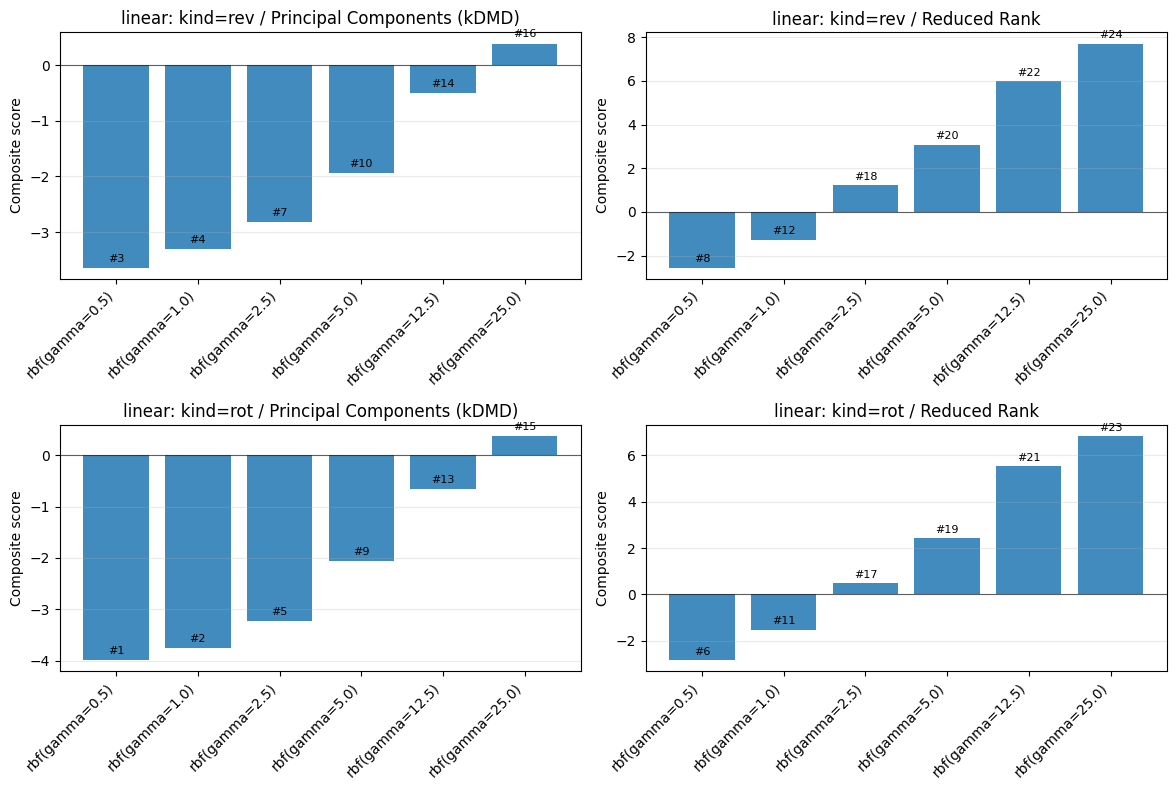

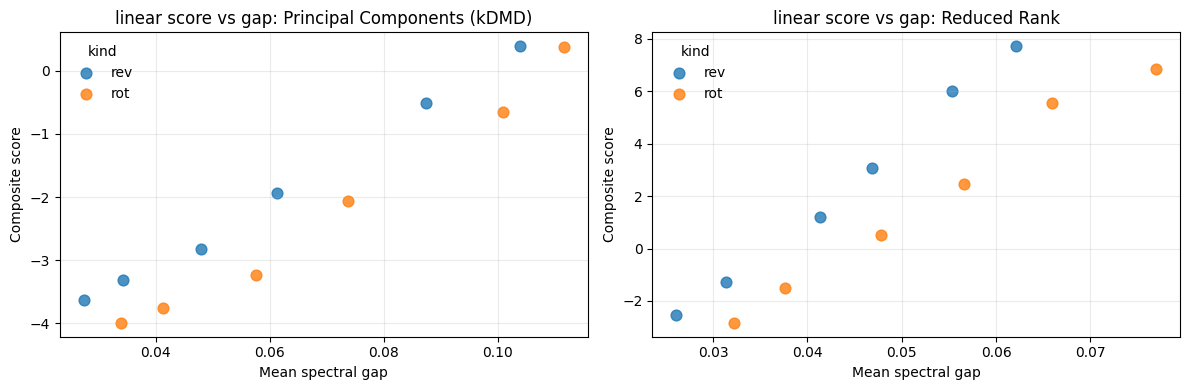

,kernel,kind,method,n_modes_used,weight_sum,agg_bias_mean,agg_bias_std,agg_dist_mean,agg_trunc_mean,agg_spurious_mean,...,mean_spurious_residual_count_norm,mean_spectral_gap_norm,std_spectral_gap_norm,composite_score,used_metrics,admissible,constraint_violations,rank,gap_mean,_kernel_label
0,rbf(gamma=0.5),rev,Principal Components (kDMD),3.0,1.0,0.321667,0.039139,9.869224,0.032583,0.420116,...,0.0,1.209455,-0.839431,-3.636747,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,3,0.027382,rbf(gamma=0.5)
1,rbf(gamma=1.0),rev,Principal Components (kDMD),3.0,1.0,0.475318,0.058502,10.234583,0.046401,0.467235,...,0.0,0.923834,-0.739001,-3.311376,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,4,0.034312,rbf(gamma=1.0)
2,rbf(gamma=2.5),rev,Principal Components (kDMD),3.0,1.0,0.577788,0.037192,11.351049,0.050904,0.534605,...,0.0,0.358744,-0.246052,-2.814855,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,7,0.048022,rbf(gamma=2.5)
3,rbf(gamma=5.0),rev,Principal Components (kDMD),3.0,1.0,0.532049,0.031757,12.645231,0.042151,0.595828,...,0.0,-0.184904,0.386274,-1.943989,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,10,0.061212,rbf(gamma=5.0)
4,rbf(gamma=12.5),rev,Principal Components (kDMD),3.0,1.0,0.408778,0.027945,14.930725,0.027420,0.678365,...,0.0,-1.260961,1.499476,-0.505840,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,14,0.087319,rbf(gamma=12.5)
5,rbf(gamma=25.0),rev,Principal Components (kDMD),3.0,1.0,0.303577,0.020511,17.128000,0.017749,0.738837,...,0.0,-1.946207,2.174698,0.386018,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,16,0.103945,rbf(gamma=25.0)
6,rbf(gamma=0.5),rev,Reduced Rank,3.0,1.0,4158.151715,645.081563,18.994729,218.670873,0.407480,...,0.0,1.263349,-0.833650,-2.551727,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,8,0.026075,rbf(gamma=0.5)
7,rbf(gamma=1.0),rev,Reduced Rank,3.0,1.0,10746.336466,1238.688282,22.497364,477.609455,0.450292,...,0.0,1.045519,-0.742331,-1.266656,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,12,0.031360,rbf(gamma=1.0)
8,rbf(gamma=2.5),rev,Reduced Rank,3.0,1.0,23096.819947,2720.826817,29.254478,788.305026,0.516728,...,0.0,0.634294,-0.500062,1.210418,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,18,0.041337,rbf(gamma=2.5)
9,rbf(gamma=5.0),rev,Reduced Rank,3.0,1.0,35768.219674,2644.656725,35.730193,1001.731353,0.568295,...,0.0,0.405442,-0.159820,3.075691,"agg_bias_mean, agg_dist_mean, agg_spurious_mea...",True,,20,0.046889,rbf(gamma=5.0)


In [10]:
# ------------------------------------------------------------
# RQ3: linear benchmark
# ------------------------------------------------------------

import itertools

from scipy.linalg import expm

from kooplearn.datasets import make_linear_system


def simulate_linear_dataset(n_steps, A_continuous, dt, beta, random_state, x0=None):
    """
    Wrapper around kooplearn.datasets.make_linear_system, reproducing the exact
    same first-order Euler-Maruyama discretization of
        dX = A_continuous X dt + sqrt(2/beta) dW
    that simulate_linear_ou implemented by hand — just generated via kooplearn's
    own routine (x_{t+1} = A x_t + xi_t, isotropic Gaussian xi_t) instead.
    """
    d = A_continuous.shape[0]
    A_discrete = np.eye(d) + dt * A_continuous
    noise_std = np.sqrt(2.0 * dt / beta)
    if x0 is None:
        x0 = np.zeros(d)
    df = make_linear_system(
        X0=x0,
        A=A_discrete,
        n_steps=n_steps,
        noise=noise_std,
        random_state=random_state,
    )
    return df.reset_index(drop=True)


def compute_linear_eigs(A, lag, num_components=5):
    """
    Simple reference for leading Koopman eigenvalues of linear observables:
    1, eig(exp(A*lag)), and selected quadratic products.
    """
    M = expm(A * lag)
    lam = np.linalg.eigvals(M)
    ref = [1.0 + 0j]

    for z in lam:
        ref.append(complex(z))

    for i in range(len(lam)):
        for j in range(i, len(lam)):
            ref.append(complex(lam[i] * lam[j]))

    ref = np.array(ref[:num_components], dtype=complex)
    return ref


# Parameters
dt = 1e-3
subsample = 20
n_train = 2000
n_val = 500
n_trials = 10
n_components = 5
beta = 1.0

# Define reversible and non-reversible linear cases
A_cases = {
    "rev": np.array([[-1.0, 0.0], [0.0, -2.0]], dtype=float),
    "rot": np.array([[-1.0, 2.0], [-2.0, -1.5]], dtype=float),
}

gammas = [0.5, 1.0, 2.5, 5.0, 12.5, 25.0]

n_steps_train = n_train * subsample
n_steps_val = n_val * subsample
lag = dt * subsample

trials_records_linear = []
modes_records_linear = []

for kind, gamma, method, reduced_rank in itertools.product(
    A_cases.keys(),
    gammas,
    ["Principal Components (kDMD)", "Reduced Rank"],
    [False, True],
):
    if method == "Principal Components (kDMD)" and reduced_rank:
        continue
    if method == "Reduced Rank" and not reduced_rank:
        continue

    A = A_cases[kind]
    vals_ref = compute_linear_eigs(A, lag=lag, num_components=n_components)

    for trial in tqdm(range(n_trials), desc=f"RQ3 {kind} / {method} / gamma={gamma}"):
        data = simulate_linear_dataset(
            n_steps=n_steps_train,
            A_continuous=A,
            dt=dt,
            beta=beta,
            random_state=1000 + trial,
            x0=np.array([0.0, 0.0]),
        ).iloc[::subsample][:n_train]

        data_val = simulate_linear_dataset(
            n_steps=n_steps_val,
            A_continuous=A,
            dt=dt,
            beta=beta,
            random_state=9000 + trial,
            x0=np.array([0.0, 0.0]),
        ).iloc[::subsample][:n_val]

        X_val = data_val.iloc[:-1].values
        Y_val = data_val.iloc[1:].values

        model = KernelRidge(
            n_components=n_components,
            reduced_rank=reduced_rank,
            gamma=gamma,
            kernel="rbf",
            alpha=1e-6,
            random_state=trial,
        )
        model.fit(data)

        n = model.kernel_X_.shape[0]
        C = model.kernel_X_ / n
        T = model.kernel_YX_ / n

        vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
        sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
        vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

        gap = spectral_gap(vals_hat)
        n_spur = spurious_ref(vals_hat, vals_ref, delta=0.1)

        vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
        _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)

        assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
            "eig() ordering changed between calls"
        )

        psi_X_val = psi_X_val_raw[:, sort_perm]
        psi_Y_val = psi_Y_val_raw[:, sort_perm]

        n_residual, spur_scores = spurious_residual(
            vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
        )

        fit_rank = model.rank_
        rho = (
            kdmd_truncation(C, fit_rank)
            if method == "Principal Components (kDMD)"
            else rrr_truncation(C, T, fit_rank)
        )

        trials_records_linear.append(
            {
                "kind": kind,
                "kernel": f"rbf(gamma={gamma})",
                "method": method,
                "trial": trial,
                "spurious_ref_count": int(n_spur),
                "spurious_residual_count": int(n_residual),
                "spectral_gap": float(gap),
                "rank": fit_rank,
            }
        )

        n_modes = min(model.rank_, funcs_hat.shape[1])
        for j in range(n_modes):
            bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
            modes_records_linear.append(
                {
                    "kind": kind,
                    "kernel": f"rbf(gamma={gamma})",
                    "method": method,
                    "trial": trial,
                    "eigenfunction_id": j + 1,
                    "spectral_bias": float(bias),
                    "metric_distortion": float(distortion),
                    "truncation": float(rho),
                    "residual_spurious_score": float(spur_scores[j]),
                    "spectral_gap": float(gap),
                    "est_eig_real": float(np.real(vals_hat[j])),
                    "est_eig_imag": float(np.imag(vals_hat[j])),
                    "gap": float(gap),
                }
            )

modes_df_linear, trials_df_linear, summary_linear, corr_df_linear, fig1_linear, fig2_linear = (
    analyse_spectrum(modes_records_linear, trials_records_linear, out_prefix="linear_ou")
)

mode_agg_linear, kernel_scores_linear = kernel_spectral_score(
    summary_linear,
    trials_df_linear,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.0,
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.0,
        "mean_spectral_gap": 0.5,
        "std_spectral_gap": 0.25,
    },
    hard_constraints={
        "max_spurious_ref_count": 4,
        "max_spurious_residual_count": 5,
    },
)

kernel_scores_linear = kernel_scores_linear.sort_values(
    ["kind", "method", "rank", "kernel"]
).reset_index(drop=True)
kernel_scores_linear.to_csv("linear_kernel_ranking.csv", index=False)


print(summary_linear.head())
print(kernel_scores_linear.head(20))
plot_kernel_rankings(kernel_scores_linear, trials_df_linear, prefix="linear")


### Hamiltonian harmonic oscillator
State:

$x=(q,p)$ (position, momentum)

Dynamics:

$\dot{q}=p$

$\dot{p}=−q$

i.e. the standard unit‑frequency harmonic oscillator, which is Hamiltonian and time‑reversible with involution $π(q,p)=(q,−p)$.

Analytic flow:

$q(t)=q_0 \cos{t}+p_0 \sin{t}$

$p(t)=−q_0\sin{t}+p_0 \cos{t}$

In [ ]:
# Parameters
dt = 1e-3
subsample = 20
n_train = 2000
n_val = 500
n_trials = 10
n_components = 5
n_steps_train = n_train * subsample
n_steps_val = n_val * subsample

gammas = [0.5, 1.0, 2.5, 5.0, 12.5, 25.0]  # rbf bandwidth
# Harmonic oscillator parameters
n_initial = 256
t_max = 50
n_steps = n_steps_train + n_steps_val
init_radius = 1.0
omega = 1.0  # angular frequency

K_decay = 4  # observe ~4 decay times for damped regimes — enough to see decay, not enough to vanish/blow up
K_periods = 10  # for damping=0 (no decay timescale exists), observe ~10 oscillation periods instead


def t_max_for_damping(damping, omega):
    if damping == 0.0:
        period = 2 * np.pi / omega
        return K_periods * period
    tau_decay = 1.0 / damping
    return K_decay * tau_decay


def harmonic_oscillator_flow(q0, p0, t, omega=1.0, damping=0.0):
    """
    Analytic flow for the (possibly damped) harmonic oscillator:
        dq/dt = p
        dp/dt = -omega^2 * q - 2*damping * p
    Handles all three regimes: under-damped (0<=damping<omega),
    critically damped (damping==omega), over-damped (damping>omega).
    """
    t = np.asarray(t, dtype=float)

    if damping == 0.0:
        q_t = q0 * np.cos(omega * t) + (p0 / omega) * np.sin(omega * t)
        p_t = -q0 * omega * np.sin(omega * t) + p0 * np.cos(omega * t)
        return q_t, p_t

    disc = omega**2 - damping**2

    if disc > 0.0:
        # Under-damped — your original formula, unchanged
        omega_d = np.sqrt(disc)
        A = q0
        B = (p0 + damping * q0) / omega_d
        exp_term = np.exp(-damping * t)
        cos_term = np.cos(omega_d * t)
        sin_term = np.sin(omega_d * t)
        q_t = exp_term * (A * cos_term + B * sin_term)
        dqdt_inner = -A * omega_d * sin_term + B * omega_d * cos_term
        p_t = exp_term * (dqdt_inner - damping * (A * cos_term + B * sin_term))
        return q_t, p_t

    elif disc == 0.0:
        # Critically damped: q(t) = (A + B t) e^{-damping t}
        A = q0
        B = p0 + damping * q0
        exp_term = np.exp(-damping * t)
        q_t = exp_term * (A + B * t)
        p_t = exp_term * (B - damping * (A + B * t))
        return q_t, p_t

    else:
        # Over-damped: q(t) = C1 e^{r1 t} + C2 e^{r2 t}, real distinct roots
        omega_o = np.sqrt(-disc)  # = sqrt(damping^2 - omega^2)
        r1 = -damping + omega_o
        r2 = -damping - omega_o
        C1 = (p0 - r2 * q0) / (r1 - r2)
        C2 = q0 - C1
        q_t = C1 * np.exp(r1 * t) + C2 * np.exp(r2 * t)
        p_t = C1 * r1 * np.exp(r1 * t) + C2 * r2 * np.exp(r2 * t)
        return q_t, p_t


def generate_ho(
    n_initial=n_initial,
    t_max=t_max,
    n_steps=n_steps,
    init_radius=init_radius,
    seed=10_000,
    omega=1.0,
    damping=0.0,
):
    rng = np.random.default_rng(seed)

    # Sample initial conditions roughly uniformly in a disk in (q,p)
    angles = rng.uniform(0.0, 2.0 * np.pi, size=n_initial)
    radii = init_radius * np.sqrt(rng.uniform(0.0, 1.0, size=n_initial))
    q0 = radii * np.cos(angles)
    p0 = radii * np.sin(angles)

    # Time grid
    t_grid = np.linspace(0.0, t_max, n_steps)

    # Forward trajectories: shape (n_initial, n_steps, 2)
    Q = np.empty((n_initial, n_steps), dtype=float)
    P = np.empty((n_initial, n_steps), dtype=float)
    for i in range(n_initial):
        q_t, p_t = harmonic_oscillator_flow(q0[i], p0[i], t_grid, omega=omega, damping=damping)
        Q[i] = q_t
        P[i] = p_t

    X_forward = np.stack([Q, P], axis=-1)  # (n_initial, n_steps, 2)

    # Time-reversed trajectories under pi(q,p) = (q,-p):
    # start from pi(q_T, p_T) and run backwards in t
    # Exact reversal only holds for gamma=0; for gamma>0 this is a diagnostic, not a symmetry.
    Q_rev = np.empty_like(Q)
    P_rev = np.empty_like(P)
    for i in range(n_initial):
        q_T = Q[i, -1]
        p_T = P[i, -1]
        # apply time-reversal involution pi
        q0_rev, p0_rev = q_T, -p_T
        q_rev_t, p_rev_t = harmonic_oscillator_flow(q0_rev, p0_rev, -t_grid, omega, damping)
        Q_rev[i] = q_rev_t
        P_rev[i] = p_rev_t

    X_reverse = np.stack([Q_rev, P_rev], axis=-1)

    return {
        "t_grid": t_grid,
        "q0": q0,
        "p0": p0,
        "omega": omega,
        "damping": damping,
        "X_forward": X_forward,  # training data for forward Koopman
        "X_reverse": X_reverse,  # explicit time-reversed trajectories
    }


def compute_linear_eigs(A, lag, num_components=5):
    """
    Simple reference for leading Koopman eigenvalues of linear observables:
    1, eig(exp(A*lag)), and selected quadratic products.
    """
    M = expm(A * lag)
    lam = np.linalg.eigvals(M)
    ref = [1.0 + 0j]

    for z in lam:
        ref.append(complex(z))

    for i in range(len(lam)):
        for j in range(i, len(lam)):
            ref.append(complex(lam[i] * lam[j]))

    ref = np.array(ref[:num_components], dtype=complex)
    return ref


trials_records_ho = []
modes_records_ho = []

damping_regimes = [0.0, 0.1 * omega, 0.3 * omega, 0.5 * omega, omega, 1.5 * omega]

for damping in damping_regimes:
    kind = f"damping={damping}"

    # Continuous-time matrix for this damped HO:
    # dq/dt = p
    # dp/dt = -omega^2 q - 2*damping p

    t_max_regime = t_max_for_damping(damping, omega)
    dt_grid = t_max_regime / (n_steps - 1)  # actual physical spacing this regime will use
    lag = dt_grid * subsample

    # sample and printy per-regime magnitude/scale diagnostics
    # before expensive kernel-fitting loop
    sample = generate_ho(
        n_initial=1, t_max=t_max_regime, n_steps=n_steps, seed=0, omega=omega, damping=damping
    )
    fwd_range = np.abs(sample["X_forward"]).max()
    rev_range = np.abs(sample["X_reverse"]).max()
    print(
        f"damping={damping:.2f}  t_max={t_max_regime:.2f}  fwd max={fwd_range:.3g}  rev max={rev_range:.3g}"
    )

    A_ho = np.array([[0.0, 1.0], [-(omega**2), -2.0 * damping]], dtype=float)
    vals_ref = compute_linear_eigs(A_ho, lag=lag, num_components=n_components)

    for method, reduced_rank in zip(
        ["Principal Components (kDMD)", "Reduced Rank"],
        [False, True],
    ):
        for gamma in tqdm(gammas, desc=f"{method} / damping={damping}"):
            for trial in range(n_trials):
                seed = 10_000 + trial
                data = generate_ho(
                    n_initial=1,
                    t_max=t_max_regime,
                    n_steps=n_steps,
                    init_radius=init_radius,
                    seed=seed,
                    omega=omega,
                    damping=damping,
                )
                ...

                # Extract the single trajectory (shape (n_steps, 2))
                X_fwd = data["X_forward"][0]  # (n_steps, 2)
                X_rev = data["X_reverse"][0]  # (n_steps, 2)

                # Subsample and split into train/val
                X_fwd = X_fwd[::subsample]
                X_rev = X_rev[::subsample]

                X_train = X_fwd[:n_train]
                data_val = X_rev[:n_val]

                # Build DataFrames for KernelRidge
                df_train = pd.DataFrame(X_train, columns=["q", "p"])
                df_val = pd.DataFrame(data_val, columns=["q", "p"])

                X_val = df_val.iloc[:-1].values
                Y_val = df_val.iloc[1:].values

                model = KernelRidge(
                    n_components=n_components,
                    reduced_rank=reduced_rank,
                    gamma=gamma,
                    kernel="rbf",
                    alpha=1e-10,
                    random_state=trial,
                )
                model.fit(df_train)

                n = model.kernel_X_.shape[0]
                C = model.kernel_X_ / n
                T = model.kernel_YX_ / n

                vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
                sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
                vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

                gap = spectral_gap(vals_hat)
                n_spur = spurious_ref(vals_hat, vals_ref, delta=0.1)

                vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
                _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)

                assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
                    "eig() ordering changed between calls"
                )

                psi_X_val = psi_X_val_raw[:, sort_perm]
                psi_Y_val = psi_Y_val_raw[:, sort_perm]

                n_residual, spur_scores = spurious_residual(
                    vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
                )

                fit_rank = model.rank_
                rho = (
                    kdmd_truncation(C, fit_rank)
                    if method == "Principal Components (kDMD)"
                    else rrr_truncation(C, T, fit_rank)
                )

                trials_records_ho.append(
                    {
                        "kind": kind,
                        "kernel": f"rbf(gamma={gamma})",
                        "method": method,
                        "trial": trial,
                        "spurious_ref_count": int(n_spur),
                        "spurious_residual_count": int(n_residual),
                        "spectral_gap": float(gap),
                        "rank": fit_rank,
                    }
                )

                n_modes = min(model.rank_, funcs_hat.shape[1])
                for j in range(n_modes):
                    bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
                    modes_records_ho.append(
                        {
                            "kind": kind,
                            "kernel": f"rbf(gamma={gamma})",
                            "method": method,
                            "trial": trial,
                            "eigenfunction_id": j + 1,
                            "spectral_bias": float(bias),
                            "metric_distortion": float(distortion),
                            "truncation": float(rho),
                            "residual_spurious_score": float(spur_scores[j]),
                            "spectral_gap": float(gap),
                            "est_eig_real": float(np.real(vals_hat[j])),
                            "est_eig_imag": float(np.imag(vals_hat[j])),
                            "gap": float(gap),
                        }
                    )

modes_df_ho, trials_df_ho, summary_ho, corr_df_ho, fig1_ho, fig2_ho = analyse_spectrum(
    modes_records_ho, trials_records_ho, out_prefix="ho"
)

mode_agg_ho, kernel_scores_ho = kernel_spectral_score(
    summary_ho,
    trials_df_ho,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "agg_bias_mean": 1.0,
        "agg_dist_mean": 1.0,
        "agg_spurious_mean": 1.0,
        "agg_trunc_mean": 0.5,
        "agg_bias_std": 0.25,
        "agg_spurious_std": 0.25,
        "mean_spurious_ref_count": 0.5,
        "mean_spurious_residual_count": 1.0,
        "mean_spectral_gap": 0.5,
        "std_spectral_gap": 0.25,
    },
    hard_constraints={
        "max_spurious_ref_count": 4,
        "max_spurious_residual_count": 5,
    },
)

kernel_scores_ho = kernel_scores_ho.sort_values(["kind", "method", "rank", "kernel"]).reset_index(
    drop=True
)
kernel_scores_ho.to_csv("ho_kernel_ranking.csv", index=False)
plot_kernel_rankings(kernel_scores_ho, trials_df_ho, prefix="ho")


damping=0.00  t_max=62.83  fwd max=0.519  rev max=0.519


TypeError: 'ellipsis' object is not iterable

In [ ]:
# ------------------------------------------------------------
# RQ4: finite graph/state-space kernel experiment
# True graph kernels on node identities
# ------------------------------------------------------------

# -----------------------------
# graph / Markov chain builders
# -----------------------------
def make_cycle_graph_transition(n_nodes):
    P = np.zeros((n_nodes, n_nodes), dtype=float)
    for i in range(n_nodes):
        P[i, (i - 1) % n_nodes] = 0.5
        P[i, (i + 1) % n_nodes] = 0.5
    return P


def make_path_graph_transition(n_nodes):
    P = np.zeros((n_nodes, n_nodes), dtype=float)
    for i in range(n_nodes):
        nbrs = []
        if i > 0:
            nbrs.append(i - 1)
        if i < n_nodes - 1:
            nbrs.append(i + 1)
        for j in nbrs:
            P[i, j] = 1.0 / len(nbrs)
    return P


def graph_laplacian_from_P(P):
    A = 0.5 * (P + P.T)
    A = (A > 0).astype(float)
    np.fill_diagonal(A, 0.0)
    D = np.diag(A.sum(axis=1))
    return D - A


def stationary_dist(P, n_iter=5000):
    v = np.ones(P.shape[0]) / P.shape[0]
    for _ in range(n_iter):
        v = v @ P
    v = np.maximum(v, 0)
    v /= v.sum()
    return v


def simulate_markov_chain(P, n_steps, random_state, x0=0):
    rng = np.random.default_rng(random_state)
    states = np.empty(n_steps, dtype=int)
    states[0] = x0
    for t in range(n_steps - 1):
        states[t + 1] = rng.choice(P.shape[0], p=P[states[t]])
    return states


# -----------------------------
# graph kernels on node labels
# each input x is a 1D array carrying one integer node id
# -----------------------------
def delta_kernel():
    def kernel(x, y):
        i = int(np.asarray(x).ravel()[0])
        j = int(np.asarray(y).ravel()[0])
        return 1.0 if i == j else 0.0

    return kernel


def diffusion_kernel(L, tau):
    K = expm(-tau * L)

    def kernel(x, y):
        i = int(np.asarray(x).ravel()[0])
        j = int(np.asarray(y).ravel()[0])
        return float(K[i, j])

    return kernel


def regularized_laplacian_kernel(L, tau):
    K = np.linalg.inv(np.eye(L.shape[0]) + tau * L)

    def kernel(x, y):
        i = int(np.asarray(x).ravel()[0])
        j = int(np.asarray(y).ravel()[0])
        return float(K[i, j])

    return kernel


def resolvent_walk_kernel(P, beta):
    K = np.linalg.inv(np.eye(P.shape[0]) - beta * P)

    def kernel(x, y):
        i = int(np.asarray(x).ravel()[0])
        j = int(np.asarray(y).ravel()[0])
        return float(K[i, j])

    return kernel


# optional: exact feature map for delta kernel on finite states
def state_dataframe(states):
    return pd.DataFrame({"state": states.astype(float)})


# -----------------------------
# experiment setup
# -----------------------------
graph_cases = {
    "cycle_12": make_cycle_graph_transition(12),
    "path_12": make_path_graph_transition(12),
}

kernel_specs = [
    ("delta", None),
    ("diffusion_tau=0.3", ("diffusion", 0.3)),
    ("diffusion_tau=1.0", ("diffusion", 1.0)),
    ("reglap_tau=0.5", ("reglap", 0.5)),
    ("reglap_tau=2.0", ("reglap", 2.0)),
    ("resolvent_beta=0.3", ("resolvent", 0.3)),
    ("resolvent_beta=0.7", ("resolvent", 0.7)),
]

n_train = 2000
n_val = 500
n_trials = 10
n_components = 5

trials_records_rq4 = []
modes_records_rq4 = []

for graph_kind, kernel_name, kernel_spec, method, reduced_rank in itertools.product(
    graph_cases.keys(),
    [ks[0] for ks in kernel_specs],
    [ks[1] for ks in kernel_specs],
    ["Principal Components (kDMD)", "Reduced Rank"],
    [False, True],
):
    if method == "Principal Components (kDMD)" and reduced_rank:
        continue
    if method == "Reduced Rank" and not reduced_rank:
        continue

    # avoid mismatching the zipped kernel name/spec from product expansion
    spec_lookup = dict(kernel_specs)
    kernel_spec = spec_lookup[kernel_name]

    P = graph_cases[graph_kind]
    L = graph_laplacian_from_P(P)
    vals_ref = np.linalg.eigvals(P)
    vals_ref = vals_ref[np.argsort(-np.abs(vals_ref))][:n_components]

    if kernel_name == "delta":
        kernel = delta_kernel()
    elif kernel_spec[0] == "diffusion":
        kernel = diffusion_kernel(L, tau=kernel_spec[1])
    elif kernel_spec[0] == "reglap":
        kernel = regularized_laplacian_kernel(L, tau=kernel_spec[1])
    elif kernel_spec[0] == "resolvent":
        kernel = resolvent_walk_kernel(P, beta=kernel_spec[1])
    else:
        raise ValueError(kernel_name)

    for trial in tqdm(range(n_trials), desc=f"RQ4 {graph_kind} / {kernel_name} / {method}"):
        states_train = simulate_markov_chain(P, n_steps=n_train, random_state=1000 + trial, x0=0)
        states_val = simulate_markov_chain(P, n_steps=n_val, random_state=9000 + trial, x0=0)

        data = state_dataframe(states_train)
        data_val = state_dataframe(states_val)

        X_val = data_val.iloc[:-1].values
        Y_val = data_val.iloc[1:].values

        model = KernelRidge(
            n_components=n_components,
            reduced_rank=reduced_rank,
            kernel=kernel,
            alpha=1e-8,
            random_state=trial,
        )
        model.fit(data)

        n = model.kernel_X_.shape[0]
        C = model.kernel_X_ / n
        T = model.kernel_YX_ / n

        vals_hat, funcs_hat = model.eig(eval_right_on=model.X_fit_[:-1])
        sort_perm = np.flip(np.argsort(np.abs(vals_hat)))
        vals_hat, funcs_hat = vals_hat[sort_perm], funcs_hat[:, sort_perm]

        gap = spectral_gap(vals_hat)
        n_spur = spurious_ref(vals_hat, vals_ref, delta=0.15)

        vals_check, psi_X_val_raw = model.eig(eval_right_on=X_val)
        _, psi_Y_val_raw = model.eig(eval_right_on=Y_val)

        assert np.allclose(np.sort(np.abs(vals_check)), np.sort(np.abs(vals_hat))), (
            "eig() ordering changed between calls"
        )

        psi_X_val = psi_X_val_raw[:, sort_perm]
        psi_Y_val = psi_Y_val_raw[:, sort_perm]

        n_residual, spur_scores = spurious_residual(
            vals_hat, psi_X_val, psi_Y_val, delta=0.1, relative=True
        )

        fit_rank = model.rank_
        rho = (
            kdmd_truncation(C, fit_rank)
            if method == "Principal Components (kDMD)"
            else rrr_truncation(C, T, fit_rank)
        )

        trials_records_rq4.append(
            {
                "kind": graph_kind,
                "kernel": kernel_name,
                "method": method,
                "trial": trial,
                "spurious_ref_count": int(n_spur),
                "spurious_residual_count": int(n_residual),
                "spectral_gap": float(gap),
                "rank": fit_rank,
            }
        )

        n_modes = min(model.rank_, funcs_hat.shape[1])
        for j in range(n_modes):
            bias, distortion = spectral_bias(funcs_hat[:, j], C, rho)
            modes_records_rq4.append(
                {
                    "kind": graph_kind,
                    "kernel": kernel_name,
                    "method": method,
                    "trial": trial,
                    "eigenfunction_id": j + 1,
                    "spectral_bias": float(bias),
                    "metric_distortion": float(distortion),
                    "truncation": float(rho),
                    "residual_spurious_score": float(spur_scores[j]),
                    "spectral_gap": float(gap),
                    "est_eig_real": float(np.real(vals_hat[j])),
                    "est_eig_imag": float(np.imag(vals_hat[j])),
                    "gap": float(gap),
                }
            )

modes_df_rq4, trials_df_rq4, summary_rq4, corr_df_rq4, fig1_rq4, fig2_rq4 = analyse_spectrum(
    modes_records_rq4, trials_records_rq4, out_prefix="rq4_graph_kernel"
)

mode_agg_rq4, kernel_scores_rq4 = kernel_spectral_score(
    summary_rq4,
    trials_df_rq4,
    group_cols=("kernel", "kind", "method"),
    selected_modes=(1, 2, 3),
    mode_weights={1: 0.5, 2: 0.3, 3: 0.2},
    normalise="zscore",
    metric_weights={
        "bias": 1.0,
        "dist": 1.0,
        "spur": 1.0,
        "trunc": 0.5,
        "gap": 0.5,
        "bias_std": 0.25,
        "spur_std": 0.25,
    },
    hard_constraints={
        "max_spurious_residual_count": 5,
    },
)

kernel_scores_rq4 = kernel_scores_rq4.sort_values(["kind", "method", "rank", "kernel"]).reset_index(
    drop=True
)

print(summary_rq4.head())
print(kernel_scores_rq4.head(20))
